## Постановка задачи
*Необходимо решить задачу классификации для операций, которые по различным причинам, связанных с безопасностью, были не подтверждены клиентами банка. То есть, предстоит разработать алгоритм реализующий ядро системы антифрода для предотвращения мошеннических операций.*

Для обучения моделей предоставляются операции 100,000 клиентов за 1.5 года, организованные по времени на 4 отдельные периода:

* Pre-train, с 2023-10-01 по 2024-09-30. История операций клиентов, которую можно использовать для предобучения и извлечения признаков. Не имеет разметки по построению.
* Train, с 2024-10-01 по 2025-05-31. История операций клиентов, в которой у них появляются нежелательные операции. Имеет разметку как неподтвержденных операций (🔴 целевой класс, “красный свет”), так и подозрительных операций, подтвержденных клиентами (🟡 "желтый свет", не является целевым классом). Все остальные операции без обратной связи клиента стоит считать подтвержденными (🟢 "зеленый свет").
* Pre-test, с 2025-06-01 по 2025-08-09. История операций клиентов, которую можно использовать для классификации самих тестовых меток. Не имеет разметки, так как является частью тестовых данных.
* Test, с 2025-06-01 по 2025-08-09. Заключительный день истории операций клиентов, каждую из которых требуется классифицировать и отправить в рамках соревнования. У каждого клиента этот заключительный день выбран случайно. 

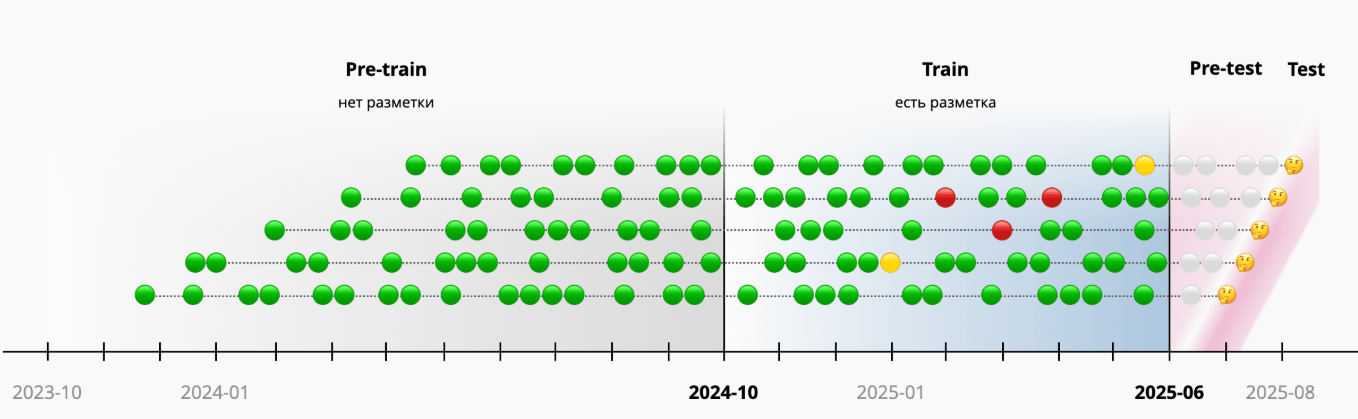

У задачи имеется ряд особенностей для исследователей и практиков анализа данных:

Целевой класс очень редкий: в тренировочных данных всего 51 тысяча неподтвержденных операций (🔴) и 36 тысяч подтвержденных (🟡). 
Алгоритм должен работать в приближенной к реальной постановке, с учетом времени. Как если бы классификатор работал здесь и сейчас, а не размечал уже ранее случившиеся инциденты пост-фактум. 
Суммарный объем данных в задаче превышает 200 миллионов операций.

Тестовые данные представляют собой 70 дней операций, сгруппированные в 10 недель. 
Отсчет идет с 2025-06-01 по 2025-08-09, первая неделя идет с 2025-06-01 по 2025-06-07, и т.д.  

Соотношение public/private в соревновании составляет 30/70 и разделено по времени (по неделям)

* customer_id – id клиента банка
* event_id — id операции
* target – целевая переменная, класс операции: 
* 1 соответствует неподтвержденной операции (🔴) 
* 0 соответствует напрямую подтвержденной клиентом операции (🟡)
* Все остальные операции в данных считаются операциями без обратной связи (🟢).

## Глоссарий данных об операциях клиентов
* customer_id – id клиента банка
* event_id — id операции
* event_dttm – дата/время операции
* event_type_nm – тип операции
* event_desc – закодировнное описание операции
* channel_indicator_type – канал совершения операции
* channel_indicator_subtype – подтип канала совершения операции
* operaton_amt — сумма операции в рублях
* currency_iso_cd – валюта операции
* mcc_code – группа MCC merchant_category_code
* pos_cd – закодированное значение point of sale condition code
* accept_language – язык заголовка http запроса
* browser_language – язык браузера
* timezone — часовой пояс
* session_id – идентификатор сессии
* operating_system_type – закодированное значение операционной системы
* battery – заряд устройства
* device_system_version – версия операционной системы
* screen_size – разрешение экрана
* developer_tools — настройки разработчика (флаг на устройстве)
* phone_voip_call_state – флаг события VoIP-звонка во время проведения операции
* web_rdp_connection – флаг наличия удаленного управления над устройством
* compromised – наличие Root-доступа на устройстве

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import warnings
import matplotlib.pyplot as plt
import seaborn as sns 
warnings.filterwarnings('ignore')

### 1 посмотрим на данные которые должны получиться

In [2]:
labels = pd.read_parquet('/kaggle/input/datasets/dianahamidullina/finish-result/train_labels.parquet')
labels

,customer_id,event_id,target
0,123123123123129,124093788813382,0
1,123123123123138,126035112904381,0
2,123123123123169,124325714018852,1
3,123123123123169,124944191029616,1
4,123123123123169,126395888234936,1
...,...,...,...
87509,124265584425399,125837544714361,1
87510,124265584425399,126370121077875,1
87511,124265584425436,124068018625936,1
87512,124265584425461,124600592844754,1


### 2 посмотрим на тестовые данные, чтобы понимать что нужно предсказать 

In [ ]:
test_df = pd.read_parquet('/kaggle/input/datasets/dianahamidullina/test-data/test.parquet')
test_df

In [ ]:
test_df.isna().sum()

In [ ]:
test_df.describe()

In [ ]:
test_df['customer_id'].nunique()

## Что должно получиться на выходе 

In [3]:
submit = pd.read_csv('/kaggle/input/datasets/dianahamidullina/finish-result/sample_submit.csv')
submit

,event_id,predict
0,125854726334416,-0.984226
1,125949211749418,-1.141220
2,124437385134670,-0.869487
3,124394437682654,-0.869487
4,123973531121838,-1.039899
...,...,...
633678,125304968700392,-1.196618
633679,123930579661188,-0.869487
633680,123140303897433,-0.869487
633681,124325714300234,-0.869487


In [ ]:
train_ops = pd.read_parquet('/kaggle/input/datasets/dianahamidullina/train-ds/train_part_1.parquet')
train_ops.columns

In [ ]:
train_ops

In [ ]:
target_dist = labels['target'].value_counts()
target_dist

In [ ]:
print(f"\nУникальных event_id в labels: {labels['event_id'].nunique()}")
print(f"Всего записей: {len(labels)}")
print(f"Дубликатов: {len(labels) - labels['event_id'].nunique()}")

In [ ]:
red_customers = labels[labels['target'] == 1]['customer_id'].unique()
yellow_customers = labels[labels['target'] == 0]['customer_id'].unique()
print(f"\nКлиентов с красными: {len(red_customers):,}")
print(f"Клиентов с желтыми: {len(yellow_customers):,}")
print(f"Клиентов и с красными и желтыми: {len(set(red_customers) & set(yellow_customers)):,}")

## Проведем детальный анализ таргета

In [ ]:
target_dist = labels['target'].value_counts()
target_dist

### соединим тренировочную выборку с таргетом

In [ ]:
print(train_ops.shape, labels.shape)

In [ ]:
train_full = train_ops.merge(labels, on='event_id', how='left') #берем все данные из таблицы трейна и добавляем лайблы
train_full['target'] = train_full['target'].fillna(-1).astype(int) #заполним пропуски -1

In [ ]:
train_full

In [ ]:
print(f"Зеленые (target=-1): {(train_full['target'] == -1).sum():,} ({(train_full['target'] == -1).mean()*100:.2f}%)")
print(f"Желтые (target=0): {(train_full['target'] == 0).sum():,} ({(train_full['target'] == 0).mean()*100:.2f}%)")
print(f"Красные (target=1): {(train_full['target'] == 1).sum():,} ({(train_full['target'] == 1).mean()*100:.2f}%)")

In [ ]:
red_in_ops = train_full[train_full['target'] == 1]['event_id'].nunique()
red_in_labels = labels[labels['target'] == 1]['event_id'].nunique()
print(f"\nКрасных в labels: {red_in_labels:,}")
print(f"Красных нашлось в операциях: {red_in_ops:,}")
if red_in_ops < red_in_labels:
    print(f"  Не все красные операции есть в train_part_1!")
    print(f"   Потеряно: {red_in_labels - red_in_ops:,} операций")
    print(f"   Они в других частях train данных")

## EDA

In [ ]:
train_full['event_dttm'] = pd.to_datetime(train_full['event_dttm'])
train_full['hour'] = train_full['event_dttm'].dt.hour
train_full['dayofweek'] = train_full['event_dttm'].dt.dayofweek
train_full['month'] = train_full['event_dttm'].dt.month
train_full['date'] = train_full['event_dttm'].dt.date

# 1. Распределение по часам
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
for target, color in [(-1, 'green'), (0, 'yellow'), (1, 'red')]:
    data = train_full[train_full['target'] == target]['hour']
    if len(data) > 0:
        plt.hist(data, bins=24, alpha=0.5, color=color, label=labels, density=True)
plt.xlabel('Час дня')
plt.ylabel('Плотность')
plt.title('Распределение по часам')
plt.legend()

plt.subplot(2, 3, 2)
for target, color in [(-1, 'green'), (0, 'yellow'), (1, 'red')]:
    data = train_full[train_full['target'] == target]['dayofweek']
    if len(data) > 0:
        plt.hist(data, bins=7, alpha=0.5, color=color, label=labels, density=True)
plt.xlabel('День недели')
plt.ylabel('Плотность')
plt.title('Распределение по дням недели')
plt.legend()

plt.subplot(2, 3, 3)
for target, color, label in [(-1, 'green', '🟢'), (0, 'yellow', '🟡'), (1, 'red', '🔴')]:
    data = train_full[train_full['target'] == target]['operaton_amt']
    if len(data) > 0:
        plt.hist(np.log1p(data), bins=50, alpha=0.5, color=color, label=labels, density=True)
plt.xlabel('log(сумма)')
plt.ylabel('Плотность')
plt.title('Распределение сумм (log scale)')
plt.legend()

plt.subplot(2, 3, 4)
type_red = train_full[train_full['target'] == 1]['event_type_nm'].value_counts(normalize=True).head(10)
type_green = train_full[train_full['target'] == -1]['event_type_nm'].value_counts(normalize=True).head(10)
type_yellow = train_full[train_full['target'] == 0]['event_type_nm'].value_counts(normalize=True).head(10)

x = range(10)
plt.bar(x, type_red.values, alpha=0.5, color='red', width=0.25)
plt.bar([i+0.25 for i in x], type_green.values if len(type_green) >= 10 else [0]*10, alpha=0.5, color='green', label='🟢', width=0.25)
plt.bar([i+0.5 for i in x], type_yellow.values if len(type_yellow) >= 10 else [0]*10, alpha=0.5, color='yellow', label='🟡', width=0.25)
plt.xlabel('Тип операции')
plt.ylabel('Доля')
plt.title('Топ-10 типов операций')
plt.legend()

plt.subplot(2, 3, 5)
channel_red = train_full[train_full['target'] == 1]['channel_indicator_type'].value_counts(normalize=True)
channel_green = train_full[train_full['target'] == -1]['channel_indicator_type'].value_counts(normalize=True)
channel_yellow = train_full[train_full['target'] == 0]['channel_indicator_type'].value_counts(normalize=True)

channels = list(set(channel_red.index) | set(channel_green.index) | set(channel_yellow.index))
for i, channel in enumerate(channels[:8]):
    red_val = channel_red.get(channel, 0)
    green_val = channel_green.get(channel, 0)
    yellow_val = channel_yellow.get(channel, 0)
    plt.bar(i, red_val, color='red', alpha=0.5, width=0.25)
    plt.bar(i+0.25, green_val, color='green', alpha=0.5, width=0.25)
    plt.bar(i+0.5, yellow_val, color='yellow', alpha=0.5, width=0.25)
plt.xlabel('Канал')
plt.ylabel('Доля')
plt.title('Распределение по каналам')


# Временной ряд
plt.subplot(2, 3, 6)
daily_ops = train_full.groupby(['date', 'target']).size().unstack(fill_value=0)
daily_ops.columns = ['🟢' if col == -1 else '🟡' if col == 0 else '🔴' for col in daily_ops.columns]
daily_ops.plot(ax=plt.gca())
plt.xlabel('Дата')
plt.ylabel('Количество операций')
plt.title('Операции по дням')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Берем случайные красные операции
red_examples = train_full[train_full['target'] == 1].sample(min(5, (train_full['target'] == 1).sum()))

for idx, row in red_examples.iterrows():
    print(f"\n Красная операция {idx}:")
    print(f"   Клиент: {row['customer_id_x']}")
    print(f"   Время: {row['event_dttm']}")
    print(f"   Тип: {row['event_type_nm']}")
    print(f"   Сумма: {row['operaton_amt']:,.2f} руб")
    print(f"   Канал: {row['channel_indicator_type']} / {row['channel_indicator_sub_type']}")
    print(f"   Устройство: OS={row['operating_system_type']}, Root={row['compromised']}")
    
    # Смотрим историю этого клиента
    customer_history = train_full[
        (train_full['customer_id_x'] == row['customer_id_x']) & 
        (train_full['event_dttm'] < row['event_dttm'])
    ].sort_values('event_dttm', ascending=False).head(5)
    
    if len(customer_history) > 0:
        print(f"   Последние 5 операций клиента до этого:")
        for _, hist_row in customer_history.iterrows():
            status = "🟢" if hist_row['target'] == -1 else "🟡" if hist_row['target'] == 0 else "🔴"
            print(f"     {status} {hist_row['event_dttm']} | {hist_row['operaton_amt']:,.0f} руб | {hist_row['event_type_nm']}")

In [ ]:
missing = train_full.isnull().sum()
missing_pct = missing / len(train_full) * 100
missing_df = pd.DataFrame({'Пропусков': missing, '%': missing_pct})
missing_df = missing_df[missing_df['Пропусков'] > 0].sort_values('Пропусков', ascending=False)

if len(missing_df) > 0:
    print("\nКолонки с пропусками:")
    print(missing_df)
else:
    print("\nПропусков нет!")

# Уникальные значения
print("\nУникальные значения в категориальных колонках:")
cat_cols = ['event_type_nm', 'channel_indicator_type', 'channel_indicator_sub_type', 
            'currency_iso_cd', 'mcc_code', 'pos_cd', 'operating_system_type']
for col in cat_cols:
    if col in train_full.columns:
        n_unique = train_full[col].nunique()
        print(f"   {col}: {n_unique} уникальных значений")

так как очень много расхождений с тарегетом, добавим все остальные трейны 

In [1]:
import psutil
import os

memory = psutil.virtual_memory()
print(f"Всего памяти: {memory.total / 1024**3:.1f} GB")
print(f"Доступно: {memory.available / 1024**3:.1f} GB")
print(f"Используется: {memory.used / 1024**3:.1f} GB")

Всего памяти: 31.4 GB
Доступно: 30.1 GB
Используется: 0.9 GB


# Начнем с последовательной обработки и очистки признаков с трейнов

In [4]:
import pandas as pd
import numpy as np

def load_and_optimize(file_path):
    
    df = pd.read_parquet(file_path)
    
    for col in df.columns:
        # Пропускаем ID
        if col in ['customer_id', 'event_id']:
            continue
            
        if df[col].dtype == 'object':
            df[col] = df[col].astype('category')
        elif df[col].dtype == 'int64':
            # Проверяем диапазон
            if df[col].max() < 2**31:
                df[col] = df[col].astype('int32')
        elif df[col].dtype == 'float64':
            df[col] = df[col].astype('float32')
    
    return df

In [4]:
train_part1 = load_and_optimize('/kaggle/input/datasets/dianahamidullina/train-ds/train_part_1.parquet')
print(f"Загружено: {len(train_part1):,} операций")
print(f"Память: {train_part1.memory_usage(deep=True).sum() / 1024**3:.2f} GB")

Загружено: 28,618,594 операций
Память: 3.43 GB


In [7]:
labels = pd.read_parquet('/kaggle/input/datasets/dianahamidullina/finish-result/train_labels.parquet')
print(f"Labels: {len(labels):,}")

Labels: 87,514


In [6]:
train_sample = train_part1.merge(labels, on='event_id', how='left')
train_sample['target'] = train_sample['target'].fillna(-1).astype('int8')
train_sample['is_fraud'] = (train_sample['target'] == 1).astype('int8')

# Конвертируем время и создаем временные признаки
train_sample['event_dttm'] = pd.to_datetime(train_sample['event_dttm'])
train_sample['hour'] = train_sample['event_dttm'].dt.hour
train_sample['dayofweek'] = train_sample['event_dttm'].dt.dayofweek
train_sample['month'] = train_sample['event_dttm'].dt.month


print(f"\nРазмер выборки: {len(train_sample):,} операций")
print(f"Красных в этой части: {(train_sample['target'] == 1).sum():,}")


Размер выборки: 28,618,594 операций
Красных в этой части: 17,384


In [7]:
train_sample.head(10)

,customer_id_x,event_id,event_dttm,event_type_nm,event_desc,channel_indicator_type,channel_indicator_sub_type,operaton_amt,currency_iso_cd,mcc_code,...,developer_tools,phone_voip_call_state,web_rdp_connection,compromised,customer_id_y,target,is_fraud,hour,dayofweek,month
0,123123123123129,123999300382879,2024-10-01 05:29:14,14,75,6,5,56422.0,0.0,4,...,NaN,NaN,NaN,NaN,NaN,-1,0,5,1,10
1,123123123123129,124531875713936,2024-10-01 10:17:22,7,56,4,15,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,-1,0,10,1,10
2,123123123123129,123329285580171,2024-10-01 10:20:03,3,120,6,5,300870.0,0.0,10,...,NaN,NaN,NaN,NaN,NaN,-1,0,10,1,10
3,123123123123129,124334305430665,2024-10-02 07:48:09,14,75,6,5,298458.0,0.0,1,...,NaN,NaN,NaN,NaN,NaN,-1,0,7,2,10
4,123123123123129,126215501146513,2024-10-02 11:20:40,14,75,6,5,59944.0,0.0,15,...,NaN,NaN,NaN,NaN,NaN,-1,0,11,2,10
5,123123123123129,126464610203810,2024-10-02 17:22:44,14,75,6,5,137235.0,0.0,4,...,NaN,NaN,NaN,NaN,NaN,-1,0,17,2,10
6,123123123123129,125502539036271,2024-10-03 18:24:36,14,75,6,5,107159.0,0.0,4,...,NaN,NaN,NaN,NaN,NaN,-1,0,18,3,10
7,123123123123129,123904810425848,2024-10-04 18:21:22,14,75,6,5,29388.0,0.0,4,...,NaN,NaN,NaN,NaN,NaN,-1,0,18,4,10
8,123123123123129,126198323368888,2024-10-07 12:33:21,14,75,0,5,89946.0,0.0,15,...,NaN,NaN,NaN,NaN,NaN,-1,0,12,0,10
9,123123123123129,123269153919321,2024-10-07 18:32:20,14,75,0,5,218215.0,0.0,4,...,NaN,NaN,NaN,NaN,NaN,-1,0,18,0,10


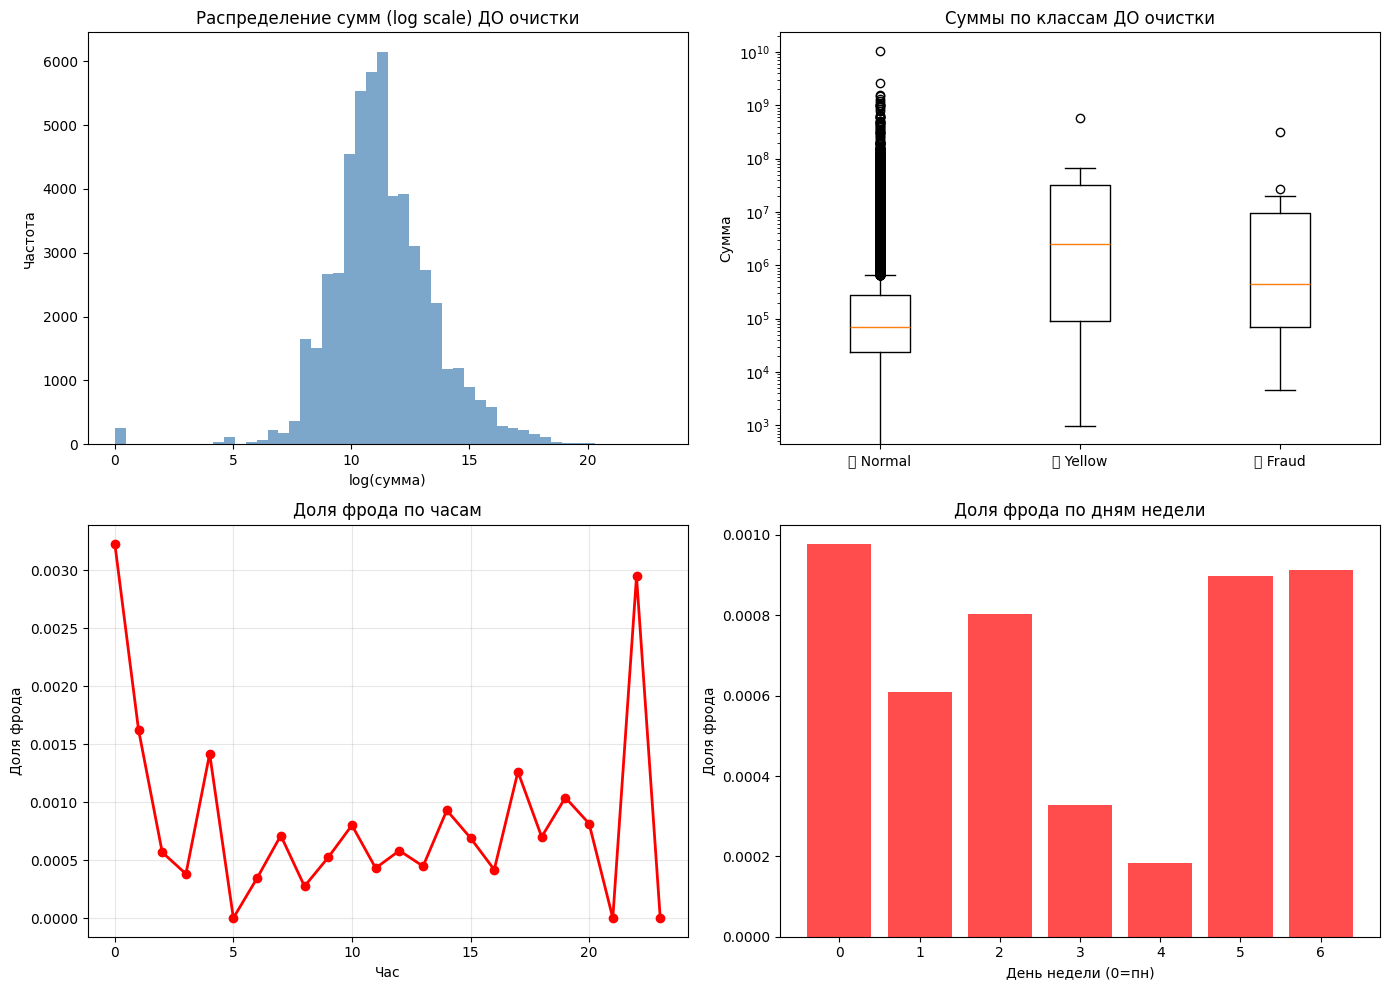

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Берем случайную подвыборку для визуализации (для скорости)
sample_for_viz = train_sample.sample(min(100000, len(train_sample)), random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Гистограмма сумм
ax1 = axes[0, 0]
amounts = sample_for_viz['operaton_amt'].dropna()
ax1.hist(np.log1p(amounts), bins=50, alpha=0.7, color='steelblue')
ax1.set_title('Распределение сумм (log scale) ДО очистки')
ax1.set_xlabel('log(сумма)')
ax1.set_ylabel('Частота')

# Box plot по классам
ax2 = axes[0, 1]
data_by_class = [
    sample_for_viz[sample_for_viz['target'] == -1]['operaton_amt'].dropna(),
    sample_for_viz[sample_for_viz['target'] == 0]['operaton_amt'].dropna(),
    sample_for_viz[sample_for_viz['target'] == 1]['operaton_amt'].dropna()
]
bp = ax2.boxplot(data_by_class, labels=['🟢 Normal', '🟡 Yellow', '🔴 Fraud'])
ax2.set_title('Суммы по классам ДО очистки')
ax2.set_ylabel('Сумма')
ax2.set_yscale('log')

# Доля фрода по часам
ax3 = axes[1, 0]
fraud_by_hour = sample_for_viz.groupby('hour')['target'].apply(lambda x: (x == 1).mean())
ax3.plot(fraud_by_hour.index, fraud_by_hour.values, 'ro-', linewidth=2)
ax3.set_title('Доля фрода по часам')
ax3.set_xlabel('Час')
ax3.set_ylabel('Доля фрода')
ax3.grid(True, alpha=0.3)

# Доля фрода по дням недели
ax4 = axes[1, 1]
fraud_by_day = sample_for_viz.groupby('dayofweek')['target'].apply(lambda x: (x == 1).mean())
ax4.bar(fraud_by_day.index, fraud_by_day.values, color='red', alpha=0.7)
ax4.set_title('Доля фрода по дням недели')
ax4.set_xlabel('День недели (0=пн)')
ax4.set_ylabel('Доля фрода')

plt.tight_layout()
plt.show()

In [9]:
amounts = train_sample['operaton_amt'].dropna()

print(f"\nСтатистика сумм:")
print(amounts.describe())

# Метод IQR
Q1 = amounts.quantile(0.25)
Q3 = amounts.quantile(0.75)
IQR = Q3 - Q1
lower_iqr = Q1 - 1.5 * IQR
upper_iqr = Q3 + 1.5 * IQR

print(f"\nГраницы выбросов (IQR):")
print(f"Нижняя: {lower_iqr:.2f}")
print(f"Верхняя: {upper_iqr:.2f}")

# Процентили
print(f"\nПроцентили:")
for p in [90, 95, 99, 99.5, 99.9]:
    print(f"{p}%: {amounts.quantile(p/100):.2f}")

# Выбираем метод очистки (используем 99.5% перцентиль)
percentile_upper = amounts.quantile(0.995)
percentile_lower = amounts.quantile(0.005)

print(f"\nВыбраны границы (99.5% перцентиль):")
print(f"Нижняя: {percentile_lower:.2f}")
print(f"Верхняя: {percentile_upper:.2f}")

# Смотрим на фродовые операции до очистки
fraud_amounts = train_sample[train_sample['target'] == 1]['operaton_amt'].dropna()
if len(fraud_amounts) > 0:
    print(f"\nФродовые операции ДО очистки:")
    print(f"Мин: {fraud_amounts.min():.2f}")
    print(f"Медиана: {fraud_amounts.median():.2f}")
    print(f"Макс: {fraud_amounts.max():.2f}")
    print(f"99% перцентиль фрода: {fraud_amounts.quantile(0.99):.2f}")



Статистика сумм:
count    1.526523e+07
mean     2.451206e+06
std      2.125623e+08
min      0.000000e+00
25%      2.401900e+04
50%      7.125200e+04
75%      2.780960e+05
max      2.768517e+11
Name: operaton_amt, dtype: float64

Границы выбросов (IQR):
Нижняя: -357096.50
Верхняя: 659211.50

Процентили:
90%: 1250547.00
95%: 3716241.90
99%: 29988000.00
99.5%: 50752517.40
99.9%: 200500000.00

Выбраны границы (99.5% перцентиль):
Нижняя: 10.00
Верхняя: 50752517.40

Фродовые операции ДО очистки:
Мин: 0.00
Медиана: 362916.00
Макс: 1150380032.00
99% перцентиль фрода: 99650474.24



Статистика сумм ПОСЛЕ очистки:
count    1.526523e+07
mean     1.094051e+06
std      5.100384e+06
min      1.000000e+01
25%      2.401900e+04
50%      7.125200e+04
75%      2.780960e+05
max      5.075252e+07
Name: operaton_amt_clean, dtype: float64

Фродовые операции ПОСЛЕ очистки:
Мин: 10.00
Медиана: 362916.00
Макс: 50752517.40


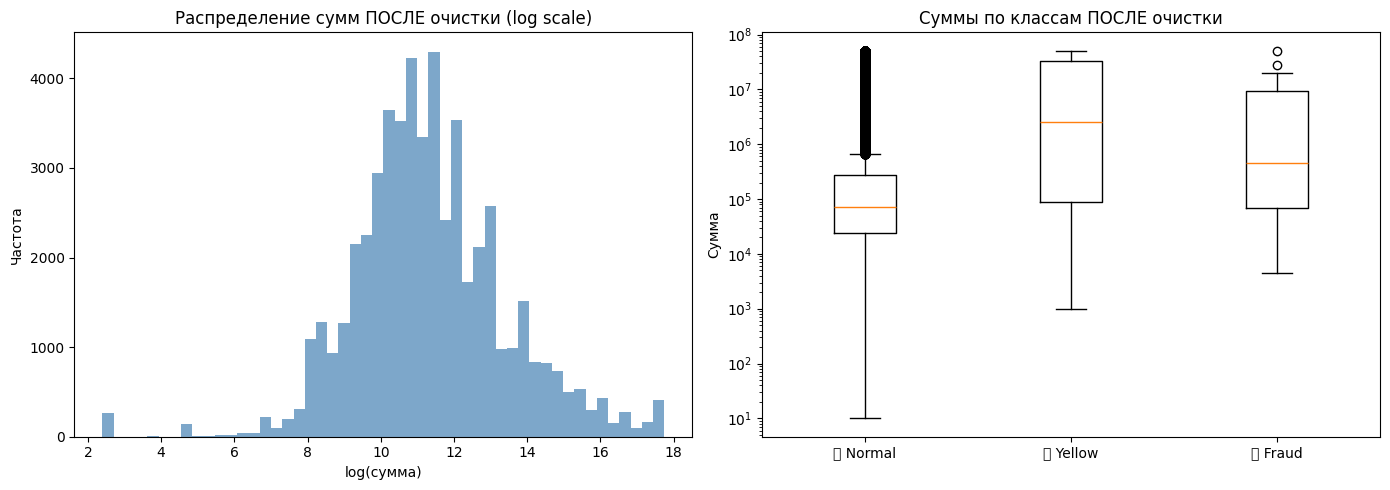

In [10]:
train_clean = train_sample.copy()

# Обрезаем суммы
train_clean['operaton_amt_clean'] = train_clean['operaton_amt'].clip(percentile_lower, percentile_upper)
train_clean['amount_log'] = np.log1p(train_clean['operaton_amt_clean'])

# Проверяем результат
amounts_clean = train_clean['operaton_amt_clean'].dropna()
print(f"\nСтатистика сумм ПОСЛЕ очистки:")
print(amounts_clean.describe())

# Смотрим на фрод после очистки
fraud_amounts_clean = train_clean[train_clean['target'] == 1]['operaton_amt_clean'].dropna()
if len(fraud_amounts_clean) > 0:
    print(f"\nФродовые операции ПОСЛЕ очистки:")
    print(f"Мин: {fraud_amounts_clean.min():.2f}")
    print(f"Медиана: {fraud_amounts_clean.median():.2f}")
    print(f"Макс: {fraud_amounts_clean.max():.2f}")

# Визуализация после очистки
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# До очистки
ax1 = axes[0]
sample_viz_clean = train_clean.sample(min(100000, len(train_clean)), random_state=42)
ax1.hist(np.log1p(sample_viz_clean['operaton_amt_clean']), bins=50, alpha=0.7, color='steelblue')
ax1.set_title('Распределение сумм ПОСЛЕ очистки (log scale)')
ax1.set_xlabel('log(сумма)')
ax1.set_ylabel('Частота')

# Box plot после очистки
ax2 = axes[1]
data_by_class_clean = [
    sample_viz_clean[sample_viz_clean['target'] == -1]['operaton_amt_clean'].dropna(),
    sample_viz_clean[sample_viz_clean['target'] == 0]['operaton_amt_clean'].dropna(),
    sample_viz_clean[sample_viz_clean['target'] == 1]['operaton_amt_clean'].dropna()
]
bp = ax2.boxplot(data_by_class_clean, labels=['🟢 Normal', '🟡 Yellow', '🔴 Fraud'])
ax2.set_title('Суммы по классам ПОСЛЕ очистки')
ax2.set_ylabel('Сумма')
ax2.set_yscale('log')

plt.tight_layout()
plt.show()


Доступные колонки для корреляции: ['operaton_amt_clean', 'amount_log', 'hour', 'dayofweek', 'month', 'event_type_nm_code', 'channel_indicator_type_code']

Топ-10 признаков, коррелирующих с фродом:
operaton_amt_clean            : 0.0215
amount_log                    : 0.0183
hour                          : 0.0042
month                         : 0.0017
event_type_nm_code            : 0.0011
dayofweek                     : -0.0021
channel_indicator_type_code   : -0.0027


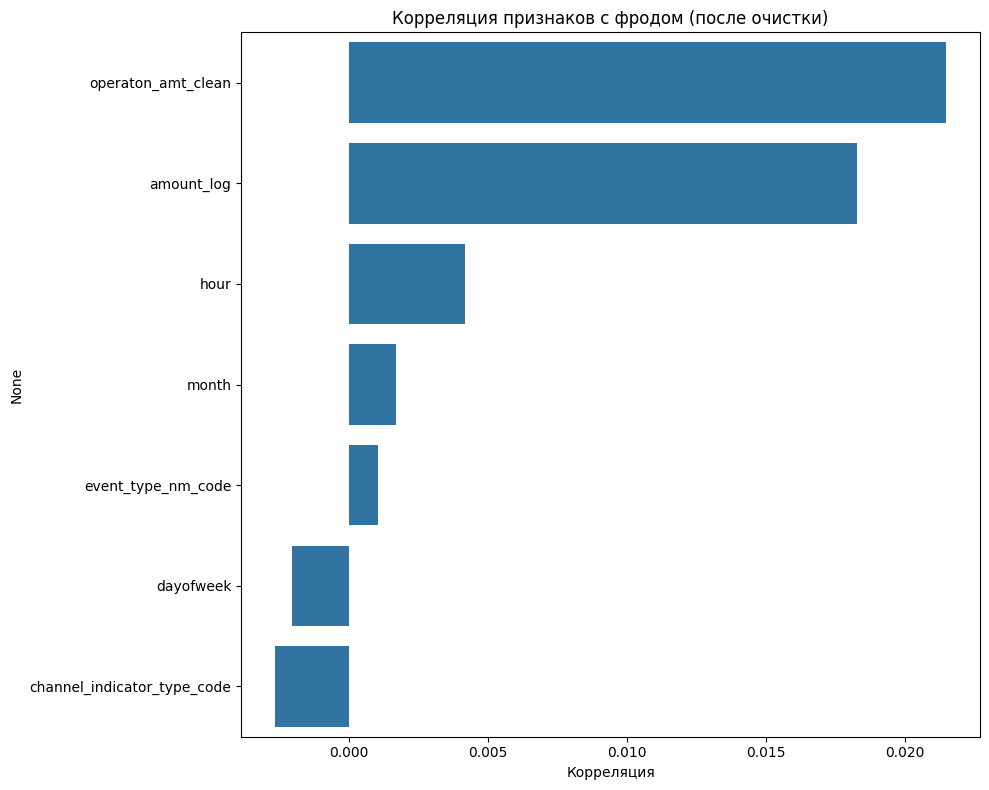

In [11]:
# Создаем данные для корреляции
corr_data = train_clean.copy()

# Добавляем кодированные категориальные
cat_cols = ['event_type_nm', 'channel_indicator_type']
for col in cat_cols:
    if col in corr_data.columns:
        corr_data[f'{col}_code'] = corr_data[col].astype('category').cat.codes

# Создаем целевой признак (уже есть is_fraud)

# Выбираем числовые колонки (все, что есть)
numeric_cols = ['operaton_amt_clean', 'amount_log', 'hour', 'dayofweek', 'month']
# Добавляем кодированные категориальные
for col in cat_cols:
    if f'{col}_code' in corr_data.columns:
        numeric_cols.append(f'{col}_code')

# Проверяем, какие колонки действительно есть
available_cols = [col for col in numeric_cols if col in corr_data.columns]
print(f"Доступные колонки для корреляции: {available_cols}")

# Корреляция с is_fraud
correlations = corr_data[available_cols + ['is_fraud']].corr()['is_fraud'].sort_values(ascending=False)

print("\nТоп-10 признаков, коррелирующих с фродом:")
for feat, corr in correlations.head(10).items():
    if feat != 'is_fraud':
        print(f"{feat:30s}: {corr:.4f}")

# Визуализация корреляции
plt.figure(figsize=(10, 8))
top_corr = correlations.head(15)
top_corr = top_corr[top_corr.index != 'is_fraud']
if len(top_corr) > 0:
    sns.barplot(x=top_corr.values, y=top_corr.index)
    plt.title('Корреляция признаков с фродом (после очистки)')
    plt.xlabel('Корреляция')
    plt.tight_layout()
    plt.show()

In [12]:
train_sample.isna().sum()

customer_id_x                        0
event_id                             0
event_dttm                           0
event_type_nm                        0
event_desc                           0
channel_indicator_type               0
channel_indicator_sub_type           0
operaton_amt                  13353367
currency_iso_cd               12996950
mcc_code                      20440094
pos_cd                        26134680
accept_language               25452822
browser_language              25968210
timezone                      25867893
session_id                    11400983
operating_system_type         25917436
battery                       25968210
device_system_version         19046803
screen_size                   19055299
developer_tools               19888868
phone_voip_call_state         22639583
web_rdp_connection            24055569
compromised                   15673439
customer_id_y                 28589128
target                               0
is_fraud                 

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr
import warnings
warnings.filterwarnings('ignore')

In [14]:
def check_linearity(df, feature, target='is_fraud'):
    """
    Проверяет линейность зависимости
    """
    # Убираем NaN
    data = df[[feature, target]].dropna()
    
    if len(data) == 0 or data[feature].nunique() < 3:
        return None
    
    # Пирсон (линейная корреляция)
    pearson_corr, pearson_p = pearsonr(data[feature], data[target])
    
    # Спирмен (монотонная корреляция)
    spearman_corr, spearman_p = spearmanr(data[feature], data[target])
    
    # Разница между корреляциями
    diff = abs(pearson_corr - spearman_corr)
    
    # Если разница > 0.1, зависимость нелинейная
    is_linear = diff < 0.1
    
    return {
        'feature': feature,
        'pearson': pearson_corr,
        'spearman': spearman_corr,
        'diff': diff,
        'is_linear': is_linear
    }

print("\nАнализ линейности зависимостей:")
print("-" * 80)
print(f"{'Признак':<30} {'Пирсон':<10} {'Спирмен':<10} {'Разница':<10} {'Линейность'}")
print("-" * 80)

linear_results = []
for col in available_cols:
    if col != 'is_fraud':
        result = check_linearity(corr_data, col)
        if result:
            linear_results.append(result)
            linear_status = "✅ Линейная" if result['is_linear'] else "⚠️ Нелинейная"
            print(f"{result['feature']:<30} {result['pearson']:<10.4f} {result['spearman']:<10.4f} {result['diff']:<10.4f} {linear_status}")

# Визуализация нелинейных зависимостей
nonlinear_features = [r for r in linear_results if not r['is_linear']]

if nonlinear_features:
    print(f"\nВизуализация нелинейных зависимостей ({len(nonlinear_features)} признаков):")
    
    n_cols = min(3, len(nonlinear_features))
    n_rows = (len(nonlinear_features) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    if n_rows == 1 and n_cols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    for i, result in enumerate(nonlinear_features):
        ax = axes[i]
        feature = result['feature']
        
        # Группируем данные для лучшей визуализации
        df_grouped = corr_data.groupby(feature)['is_fraud'].mean().reset_index()
        
        ax.scatter(df_grouped[feature], df_grouped['is_fraud'], alpha=0.5, s=20)
        ax.set_xlabel(feature)
        ax.set_ylabel('Доля фрода')
        ax.set_title(f'{feature}\nПирсон: {result["pearson"]:.3f}, Спирмен: {result["spearman"]:.3f}')
        ax.grid(True, alpha=0.3)
    
    # Убираем лишние подграфики
    for j in range(len(nonlinear_features), len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()
else:
    print("\n✅ Все зависимости линейные!")


Анализ линейности зависимостей:
--------------------------------------------------------------------------------
Признак                        Пирсон     Спирмен    Разница    Линейность
--------------------------------------------------------------------------------
operaton_amt_clean             0.0215     0.0137     0.0078     ✅ Линейная
amount_log                     0.0183     0.0137     0.0045     ✅ Линейная
hour                           0.0042     0.0041     0.0001     ✅ Линейная
dayofweek                      -0.0021    -0.0020    0.0000     ✅ Линейная
month                          0.0017     0.0011     0.0006     ✅ Линейная
event_type_nm_code             0.0011     0.0012     0.0002     ✅ Линейная
channel_indicator_type_code    -0.0027    -0.0024    0.0003     ✅ Линейная

✅ Все зависимости линейные!


In [15]:
# Список для отбора
selected_features = []

# Добавляем признаки с корреляцией > 0.001
for feat, corr in correlations.items():
    if feat != 'is_fraud' and abs(corr) > 0.001:
        selected_features.append(feat)

# Добавляем временные признаки, если их нет
time_features = ['hour', 'dayofweek', 'month']
for feat in time_features:
    if feat in corr_data.columns and feat not in selected_features:
        selected_features.append(feat)

# Добавляем важные категориальные признаки
important_cat = ['event_type_nm_code', 'channel_indicator_type_code']
for feat in important_cat:
    if feat in corr_data.columns and feat not in selected_features:
        selected_features.append(feat)

print(f"\nВыбрано признаков: {len(selected_features)}")
print("\nСписок выбранных признаков:")
for i, feat in enumerate(selected_features, 1):
    corr_val = correlations.get(feat, 0)
    print(f"{i:2d}. {feat:35s} (корреляция: {corr_val:.4f})")

# Сохраняем список
with open('selected_features_part1.txt', 'w') as f:
    for feat in selected_features:
        f.write(f"{feat}\n")

print(f"\n✅ Список признаков сохранен в 'selected_features_part1.txt'")


Выбрано признаков: 7

Список выбранных признаков:
 1. operaton_amt_clean                  (корреляция: 0.0215)
 2. amount_log                          (корреляция: 0.0183)
 3. hour                                (корреляция: 0.0042)
 4. month                               (корреляция: 0.0017)
 5. event_type_nm_code                  (корреляция: 0.0011)
 6. dayofweek                           (корреляция: -0.0021)
 7. channel_indicator_type_code         (корреляция: -0.0027)

✅ Список признаков сохранен в 'selected_features_part1.txt'


In [16]:
save_cols = ['customer_id', 'event_id', 'target', 'is_fraud', 
             'operaton_amt_clean', 'amount_log', 'hour', 'dayofweek', 'month'] + selected_features
save_cols = list(set(save_cols))  # Убираем дубликаты

# Проверяем, какие колонки есть
save_cols = [col for col in save_cols if col in train_clean.columns]

train_clean[save_cols].to_parquet('train_part1_clean.parquet', compression='snappy')
print(f"✅ Сохранено: train_part1_clean.parquet")
print(f"   Размер: {len(train_clean):,} операций")
print(f"   Признаков: {len(save_cols)}")

✅ Сохранено: train_part1_clean.parquet
   Размер: 28,618,594 операций
   Признаков: 8


In [17]:
import gc 
# Освобождаем память
del train_part1
del train_sample
del sample_for_viz
del train_clean
gc.collect()

print("Память очищена!")

Память очищена!


## Посмотрим на вторую выборку 

In [5]:
print("Загружаем только первую часть train данных...")
train_part2 = load_and_optimize('/kaggle/input/datasets/dianahamidullina/train-ds/train_part_2.parquet')
print(f"Загружено: {len(train_part2):,} операций")
print(f"Память: {train_part2.memory_usage(deep=True).sum() / 1024**3:.2f} GB")

Загружаем только первую часть train данных...
Загружено: 28,558,397 операций
Память: 3.43 GB


In [8]:
train_sample2 = train_part2.merge(labels, on='event_id', how='left')
train_sample2['target'] = train_sample2['target'].fillna(-1).astype('int8')
train_sample2['is_fraud'] = (train_sample2['target'] == 1).astype('int8')

# Конвертируем время и создаем временные признаки
train_sample2['event_dttm'] = pd.to_datetime(train_sample2['event_dttm'])
train_sample2['hour'] = train_sample2['event_dttm'].dt.hour
train_sample2['dayofweek'] = train_sample2['event_dttm'].dt.dayofweek
train_sample2['month'] = train_sample2['event_dttm'].dt.month


print(f"\nРазмер выборки: {len(train_sample2):,} операций")
print(f"Красных в этой части: {(train_sample2['target'] == 1).sum():,}")


Размер выборки: 28,558,397 операций
Красных в этой части: 17,157


/tmp/ipykernel_130/83110646.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_by_class, labels=['🟢 Normal', '🟡 Yellow', '🔴 Fraud'])
/tmp/ipykernel_130/83110646.py:46: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_130/83110646.py:46: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_130/83110646.py:46: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128993

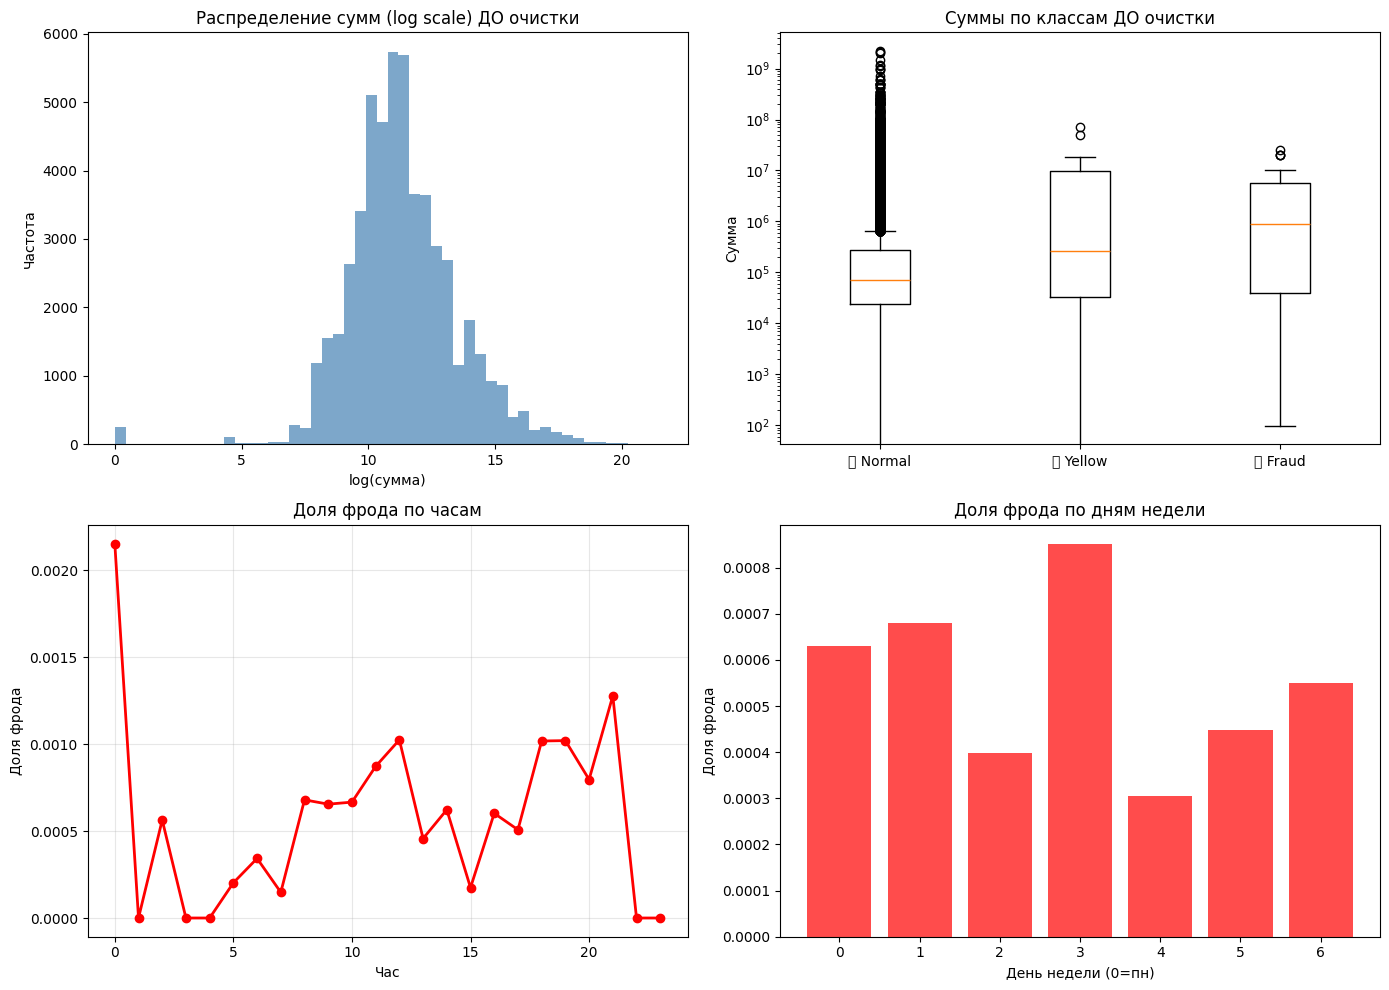

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Берем случайную подвыборку для визуализации (для скорости)
sample_for_viz = train_sample2.sample(min(100000, len(train_sample2)), random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Гистограмма сумм
ax1 = axes[0, 0]
amounts = sample_for_viz['operaton_amt'].dropna()
ax1.hist(np.log1p(amounts), bins=50, alpha=0.7, color='steelblue')
ax1.set_title('Распределение сумм (log scale) ДО очистки')
ax1.set_xlabel('log(сумма)')
ax1.set_ylabel('Частота')

# Box plot по классам
ax2 = axes[0, 1]
data_by_class = [
    sample_for_viz[sample_for_viz['target'] == -1]['operaton_amt'].dropna(),
    sample_for_viz[sample_for_viz['target'] == 0]['operaton_amt'].dropna(),
    sample_for_viz[sample_for_viz['target'] == 1]['operaton_amt'].dropna()
]
bp = ax2.boxplot(data_by_class, labels=['🟢 Normal', '🟡 Yellow', '🔴 Fraud'])
ax2.set_title('Суммы по классам ДО очистки')
ax2.set_ylabel('Сумма')
ax2.set_yscale('log')

# Доля фрода по часам
ax3 = axes[1, 0]
fraud_by_hour = sample_for_viz.groupby('hour')['target'].apply(lambda x: (x == 1).mean())
ax3.plot(fraud_by_hour.index, fraud_by_hour.values, 'ro-', linewidth=2)
ax3.set_title('Доля фрода по часам')
ax3.set_xlabel('Час')
ax3.set_ylabel('Доля фрода')
ax3.grid(True, alpha=0.3)

# Доля фрода по дням недели
ax4 = axes[1, 1]
fraud_by_day = sample_for_viz.groupby('dayofweek')['target'].apply(lambda x: (x == 1).mean())
ax4.bar(fraud_by_day.index, fraud_by_day.values, color='red', alpha=0.7)
ax4.set_title('Доля фрода по дням недели')
ax4.set_xlabel('День недели (0=пн)')
ax4.set_ylabel('Доля фрода')

plt.tight_layout()
plt.show()

In [10]:
amounts = train_sample2['operaton_amt'].dropna()

print(f"\nСтатистика сумм:")
print(amounts.describe())

# Метод IQR
Q1 = amounts.quantile(0.25)
Q3 = amounts.quantile(0.75)
IQR = Q3 - Q1
lower_iqr = Q1 - 1.5 * IQR
upper_iqr = Q3 + 1.5 * IQR

print(f"\nГраницы выбросов (IQR):")
print(f"Нижняя: {lower_iqr:.2f}")
print(f"Верхняя: {upper_iqr:.2f}")

# Процентили
print(f"\nПроцентили:")
for p in [90, 95, 99, 99.5, 99.9]:
    print(f"{p}%: {amounts.quantile(p/100):.2f}")

# Выбираем метод очистки (используем 99.5% перцентиль)
percentile_upper = amounts.quantile(0.995)
percentile_lower = amounts.quantile(0.005)

print(f"\nВыбраны границы (99.5% перцентиль):")
print(f"Нижняя: {percentile_lower:.2f}")
print(f"Верхняя: {percentile_upper:.2f}")

# Смотрим на фродовые операции до очистки
fraud_amounts = train_sample2[train_sample2['target'] == 1]['operaton_amt'].dropna()
if len(fraud_amounts) > 0:
    print(f"\nФродовые операции ДО очистки:")
    print(f"Мин: {fraud_amounts.min():.2f}")
    print(f"Медиана: {fraud_amounts.median():.2f}")
    print(f"Макс: {fraud_amounts.max():.2f}")
    print(f"99% перцентиль фрода: {fraud_amounts.quantile(0.99):.2f}")


Статистика сумм:
count    1.529900e+07
mean     2.405422e+06
std      2.683275e+08
min      0.000000e+00
25%      2.398700e+04
50%      7.063000e+04
75%      2.738345e+05
max      3.439643e+11
Name: operaton_amt, dtype: float64

Границы выбросов (IQR):
Нижняя: -350784.25
Верхняя: 648605.75

Процентили:
90%: 1210680.00
95%: 3621960.00
99%: 29859000.00
99.5%: 50360000.00
99.9%: 199960000.00

Выбраны границы (99.5% перцентиль):
Нижняя: 28.00
Верхняя: 50360000.00

Фродовые операции ДО очистки:
Мин: 0.00
Медиана: 415911.00
Макс: 1007112960.00
99% перцентиль фрода: 100130000.00



Статистика сумм ПОСЛЕ очистки:
count    15298995.0
mean      1073566.0
std       4924628.5
min            28.0
25%         23987.0
50%         70630.0
75%        273834.5
max      50360000.0
Name: operaton_amt_clean, dtype: float64

Фродовые операции ПОСЛЕ очистки:
Мин: 28.00
Медиана: 415911.00
Макс: 50360000.00


/tmp/ipykernel_130/2665557409.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_by_class_clean, labels=['🟢 Normal', '🟡 Yellow', '🔴 Fraud'])
/tmp/ipykernel_130/2665557409.py:43: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_130/2665557409.py:43: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_130/2665557409.py:43: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning

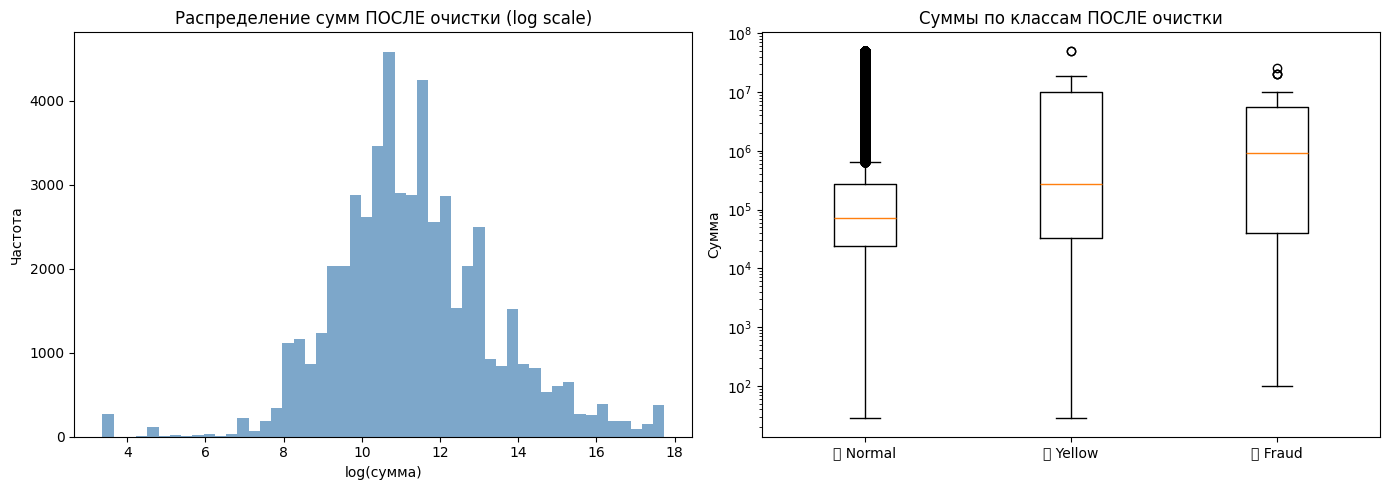

In [11]:
train_clean = train_sample2.copy()

# Обрезаем суммы
train_clean['operaton_amt_clean'] = train_clean['operaton_amt'].clip(percentile_lower, percentile_upper)
train_clean['amount_log'] = np.log1p(train_clean['operaton_amt_clean'])

# Проверяем результат
amounts_clean = train_clean['operaton_amt_clean'].dropna()
print(f"\nСтатистика сумм ПОСЛЕ очистки:")
print(amounts_clean.describe())

# Смотрим на фрод после очистки
fraud_amounts_clean = train_clean[train_clean['target'] == 1]['operaton_amt_clean'].dropna()
if len(fraud_amounts_clean) > 0:
    print(f"\nФродовые операции ПОСЛЕ очистки:")
    print(f"Мин: {fraud_amounts_clean.min():.2f}")
    print(f"Медиана: {fraud_amounts_clean.median():.2f}")
    print(f"Макс: {fraud_amounts_clean.max():.2f}")

# Визуализация после очистки
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# До очистки
ax1 = axes[0]
sample_viz_clean = train_clean.sample(min(100000, len(train_clean)), random_state=42)
ax1.hist(np.log1p(sample_viz_clean['operaton_amt_clean']), bins=50, alpha=0.7, color='steelblue')
ax1.set_title('Распределение сумм ПОСЛЕ очистки (log scale)')
ax1.set_xlabel('log(сумма)')
ax1.set_ylabel('Частота')

# Box plot после очистки
ax2 = axes[1]
data_by_class_clean = [
    sample_viz_clean[sample_viz_clean['target'] == -1]['operaton_amt_clean'].dropna(),
    sample_viz_clean[sample_viz_clean['target'] == 0]['operaton_amt_clean'].dropna(),
    sample_viz_clean[sample_viz_clean['target'] == 1]['operaton_amt_clean'].dropna()
]
bp = ax2.boxplot(data_by_class_clean, labels=['🟢 Normal', '🟡 Yellow', '🔴 Fraud'])
ax2.set_title('Суммы по классам ПОСЛЕ очистки')
ax2.set_ylabel('Сумма')
ax2.set_yscale('log')

plt.tight_layout()
plt.show()


Доступные колонки для корреляции: ['operaton_amt_clean', 'amount_log', 'hour', 'dayofweek', 'month', 'event_type_nm_code', 'channel_indicator_type_code']

Топ-10 признаков, коррелирующих с фродом:
operaton_amt_clean            : 0.0222
amount_log                    : 0.0191
hour                          : 0.0047
month                         : 0.0017
event_type_nm_code            : 0.0009
dayofweek                     : -0.0018
channel_indicator_type_code   : -0.0029


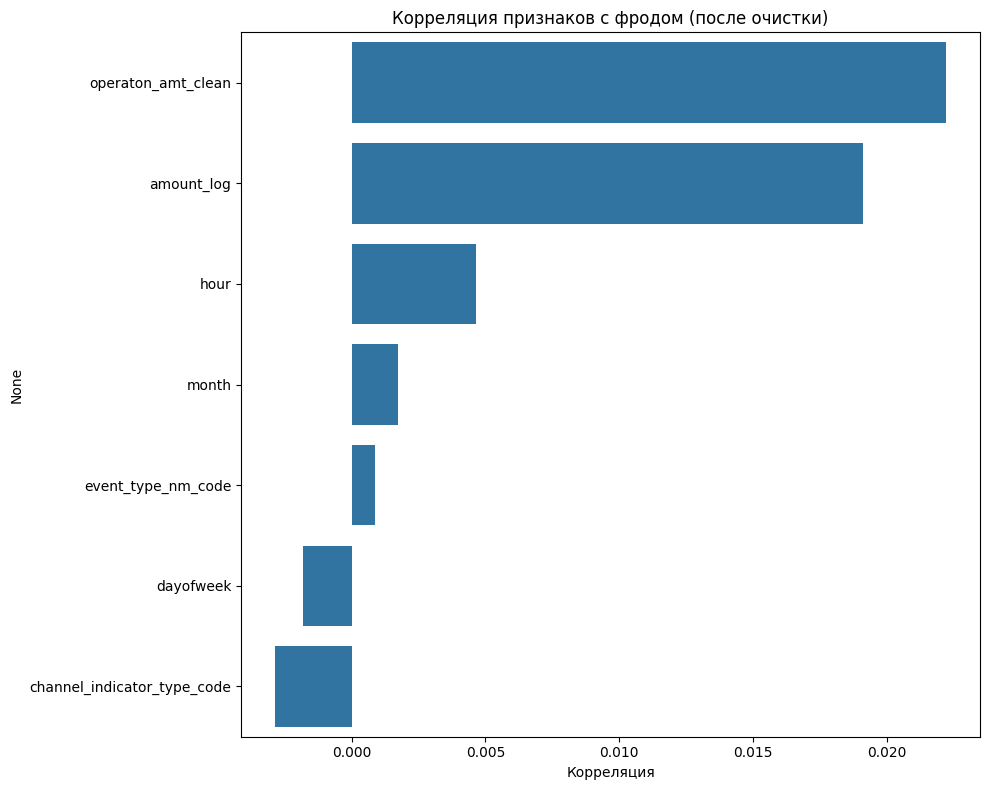

In [12]:
# Создаем данные для корреляции
corr_data = train_clean.copy()

# Добавляем кодированные категориальные
cat_cols = ['event_type_nm', 'channel_indicator_type']
for col in cat_cols:
    if col in corr_data.columns:
        corr_data[f'{col}_code'] = corr_data[col].astype('category').cat.codes

# Создаем целевой признак (уже есть is_fraud)

# Выбираем числовые колонки (все, что есть)
numeric_cols = ['operaton_amt_clean', 'amount_log', 'hour', 'dayofweek', 'month']
# Добавляем кодированные категориальные
for col in cat_cols:
    if f'{col}_code' in corr_data.columns:
        numeric_cols.append(f'{col}_code')

# Проверяем, какие колонки действительно есть
available_cols = [col for col in numeric_cols if col in corr_data.columns]
print(f"Доступные колонки для корреляции: {available_cols}")

# Корреляция с is_fraud
correlations = corr_data[available_cols + ['is_fraud']].corr()['is_fraud'].sort_values(ascending=False)

print("\nТоп-10 признаков, коррелирующих с фродом:")
for feat, corr in correlations.head(10).items():
    if feat != 'is_fraud':
        print(f"{feat:30s}: {corr:.4f}")

# Визуализация корреляции
plt.figure(figsize=(10, 8))
top_corr = correlations.head(15)
top_corr = top_corr[top_corr.index != 'is_fraud']
if len(top_corr) > 0:
    sns.barplot(x=top_corr.values, y=top_corr.index)
    plt.title('Корреляция признаков с фродом (после очистки)')
    plt.xlabel('Корреляция')
    plt.tight_layout()
    plt.show()

In [13]:
# Список для отбора
selected_features = []

# Добавляем признаки с корреляцией > 0.001
for feat, corr in correlations.items():
    if feat != 'is_fraud' and abs(corr) > 0.001:
        selected_features.append(feat)

# Добавляем временные признаки, если их нет
time_features = ['hour', 'dayofweek', 'month']
for feat in time_features:
    if feat in corr_data.columns and feat not in selected_features:
        selected_features.append(feat)

# Добавляем важные категориальные признаки
important_cat = ['event_type_nm_code', 'channel_indicator_type_code']
for feat in important_cat:
    if feat in corr_data.columns and feat not in selected_features:
        selected_features.append(feat)

print(f"\nВыбрано признаков: {len(selected_features)}")
print("\nСписок выбранных признаков:")
for i, feat in enumerate(selected_features, 1):
    corr_val = correlations.get(feat, 0)
    print(f"{i:2d}. {feat:35s} (корреляция: {corr_val:.4f})")

# Сохраняем список
with open('selected_features_part2.txt', 'w') as f:
    for feat in selected_features:
        f.write(f"{feat}\n")

print(f"\n✅ Список признаков сохранен в 'selected_features_part2.txt'")


Выбрано признаков: 7

Список выбранных признаков:
 1. operaton_amt_clean                  (корреляция: 0.0222)
 2. amount_log                          (корреляция: 0.0191)
 3. hour                                (корреляция: 0.0047)
 4. month                               (корреляция: 0.0017)
 5. dayofweek                           (корреляция: -0.0018)
 6. channel_indicator_type_code         (корреляция: -0.0029)
 7. event_type_nm_code                  (корреляция: 0.0009)

✅ Список признаков сохранен в 'selected_features_part2.txt'


In [14]:
save_cols = ['customer_id', 'event_id', 'target', 'is_fraud', 
             'operaton_amt_clean', 'amount_log', 'hour', 'dayofweek', 'month'] + selected_features
save_cols = list(set(save_cols))  # Убираем дубликаты

# Проверяем, какие колонки есть
save_cols = [col for col in save_cols if col in train_clean.columns]

train_clean[save_cols].to_parquet('train_part2_clean.parquet', compression='snappy')
print(f"✅ Сохранено: train_part2_clean.parquet")
print(f"   Размер: {len(train_clean):,} операций")
print(f"   Признаков: {len(save_cols)}")

✅ Сохранено: train_part2_clean.parquet
   Размер: 28,558,397 операций
   Признаков: 8


In [15]:
import gc 
# Освобождаем память
del train_part2
del train_sample2
del sample_for_viz
del train_clean
gc.collect()

print("Память очищена!")

Память очищена!


## Проанализируем 3ю тренировочную выборку 

In [16]:
print("Загружаем только первую часть train данных...")
train_part3 = load_and_optimize('/kaggle/input/datasets/dianahamidullina/train-ds/train_part_3.parquet')
print(f"Загружено: {len(train_part3):,} операций")
print(f"Память: {train_part3.memory_usage(deep=True).sum() / 1024**3:.2f} GB")

Загружаем только первую часть train данных...
Загружено: 28,500,849 операций
Память: 3.42 GB


In [17]:
train_sample3 = train_part3.merge(labels, on='event_id', how='left')
train_sample3['target'] = train_sample3['target'].fillna(-1).astype('int8')
train_sample3['is_fraud'] = (train_sample3['target'] == 1).astype('int8')

# Конвертируем время и создаем временные признаки
train_sample3['event_dttm'] = pd.to_datetime(train_sample3['event_dttm'])
train_sample3['hour'] = train_sample3['event_dttm'].dt.hour
train_sample3['dayofweek'] = train_sample3['event_dttm'].dt.dayofweek
train_sample3['month'] = train_sample3['event_dttm'].dt.month


print(f"\nРазмер выборки: {len(train_sample3):,} операций")
print(f"Красных в этой части: {(train_sample3['target'] == 1).sum():,}")


Размер выборки: 28,500,849 операций
Красных в этой части: 16,897


/tmp/ipykernel_130/2578891604.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_by_class, labels=['🟢 Normal', '🟡 Yellow', '🔴 Fraud'])
/tmp/ipykernel_130/2578891604.py:42: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_130/2578891604.py:42: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_130/2578891604.py:42: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyp

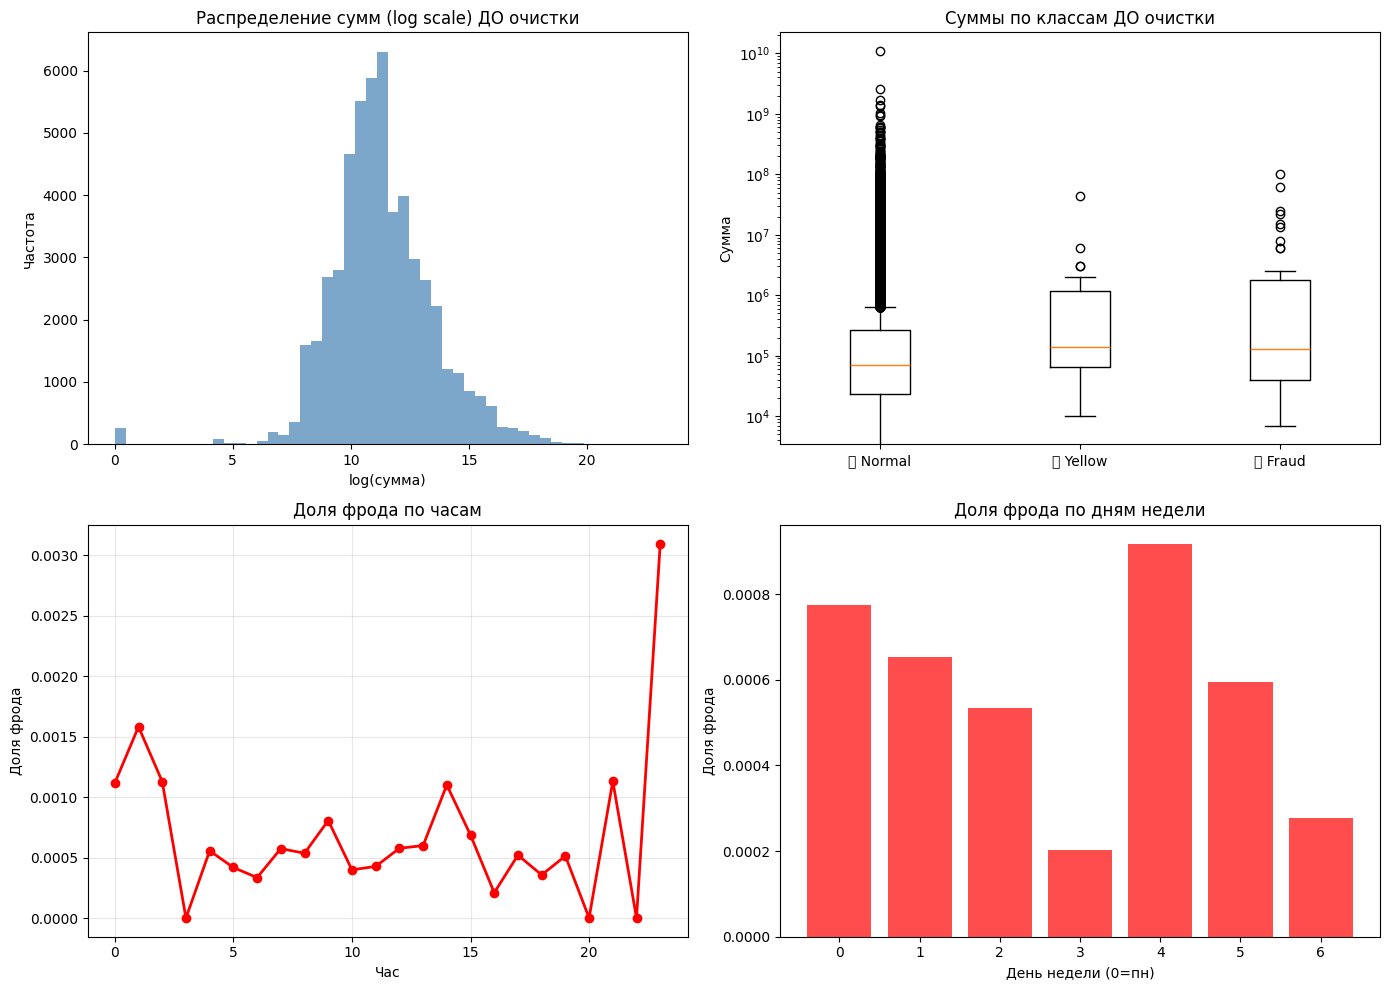

In [18]:
sample_for_viz = train_sample3.sample(min(100000, len(train_sample3)), random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Гистограмма сумм
ax1 = axes[0, 0]
amounts = sample_for_viz['operaton_amt'].dropna()
ax1.hist(np.log1p(amounts), bins=50, alpha=0.7, color='steelblue')
ax1.set_title('Распределение сумм (log scale) ДО очистки')
ax1.set_xlabel('log(сумма)')
ax1.set_ylabel('Частота')

# Box plot по классам
ax2 = axes[0, 1]
data_by_class = [
    sample_for_viz[sample_for_viz['target'] == -1]['operaton_amt'].dropna(),
    sample_for_viz[sample_for_viz['target'] == 0]['operaton_amt'].dropna(),
    sample_for_viz[sample_for_viz['target'] == 1]['operaton_amt'].dropna()
]
bp = ax2.boxplot(data_by_class, labels=['🟢 Normal', '🟡 Yellow', '🔴 Fraud'])
ax2.set_title('Суммы по классам ДО очистки')
ax2.set_ylabel('Сумма')
ax2.set_yscale('log')

# Доля фрода по часам
ax3 = axes[1, 0]
fraud_by_hour = sample_for_viz.groupby('hour')['target'].apply(lambda x: (x == 1).mean())
ax3.plot(fraud_by_hour.index, fraud_by_hour.values, 'ro-', linewidth=2)
ax3.set_title('Доля фрода по часам')
ax3.set_xlabel('Час')
ax3.set_ylabel('Доля фрода')
ax3.grid(True, alpha=0.3)

# Доля фрода по дням недели
ax4 = axes[1, 1]
fraud_by_day = sample_for_viz.groupby('dayofweek')['target'].apply(lambda x: (x == 1).mean())
ax4.bar(fraud_by_day.index, fraud_by_day.values, color='red', alpha=0.7)
ax4.set_title('Доля фрода по дням недели')
ax4.set_xlabel('День недели (0=пн)')
ax4.set_ylabel('Доля фрода')

plt.tight_layout()
plt.show()

In [19]:
amounts = train_sample3['operaton_amt'].dropna()

print(f"\nСтатистика сумм:")
print(amounts.describe())

# Метод IQR
Q1 = amounts.quantile(0.25)
Q3 = amounts.quantile(0.75)
IQR = Q3 - Q1
lower_iqr = Q1 - 1.5 * IQR
upper_iqr = Q3 + 1.5 * IQR

print(f"\nГраницы выбросов (IQR):")
print(f"Нижняя: {lower_iqr:.2f}")
print(f"Верхняя: {upper_iqr:.2f}")

# Процентили
print(f"\nПроцентили:")
for p in [90, 95, 99, 99.5, 99.9]:
    print(f"{p}%: {amounts.quantile(p/100):.2f}")

# Выбираем метод очистки (используем 99.5% перцентиль)
percentile_upper = amounts.quantile(0.995)
percentile_lower = amounts.quantile(0.005)

print(f"\nВыбраны границы (99.5% перцентиль):")
print(f"Нижняя: {percentile_lower:.2f}")
print(f"Верхняя: {percentile_upper:.2f}")

# Смотрим на фродовые операции до очистки
fraud_amounts = train_sample3[train_sample3['target'] == 1]['operaton_amt'].dropna()
if len(fraud_amounts) > 0:
    print(f"\nФродовые операции ДО очистки:")
    print(f"Мин: {fraud_amounts.min():.2f}")
    print(f"Медиана: {fraud_amounts.median():.2f}")
    print(f"Макс: {fraud_amounts.max():.2f}")
    print(f"99% перцентиль фрода: {fraud_amounts.quantile(0.99):.2f}")


Статистика сумм:
count    1.528970e+07
mean     2.135264e+06
std      1.109751e+08
min      0.000000e+00
25%      2.391400e+04
50%      7.061600e+04
75%      2.759995e+05
max      1.289030e+11
Name: operaton_amt, dtype: float64

Границы выбросов (IQR):
Нижняя: -354214.25
Верхняя: 654127.75

Процентили:
90%: 1234584.40
95%: 3704249.40
99%: 29916000.00
99.5%: 50450000.00
99.9%: 200503351.90

Выбраны границы (99.5% перцентиль):
Нижняя: 9.00
Верхняя: 50450000.00

Фродовые операции ДО очистки:
Мин: 0.00
Медиана: 357488.00
Макс: 1489800704.00
99% перцентиль фрода: 99795612.16



Статистика сумм ПОСЛЕ очистки:
count    1.528970e+07
mean     1.083452e+06
std      4.959817e+06
min      9.000000e+00
25%      2.391400e+04
50%      7.061600e+04
75%      2.759995e+05
max      5.045000e+07
Name: operaton_amt_clean, dtype: float64

Фродовые операции ПОСЛЕ очистки:
Мин: 9.00
Медиана: 357488.00
Макс: 50450000.00


/tmp/ipykernel_130/3595877315.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_by_class_clean, labels=['🟢 Normal', '🟡 Yellow', '🔴 Fraud'])
/tmp/ipykernel_130/3595877315.py:43: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_130/3595877315.py:43: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_130/3595877315.py:43: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning

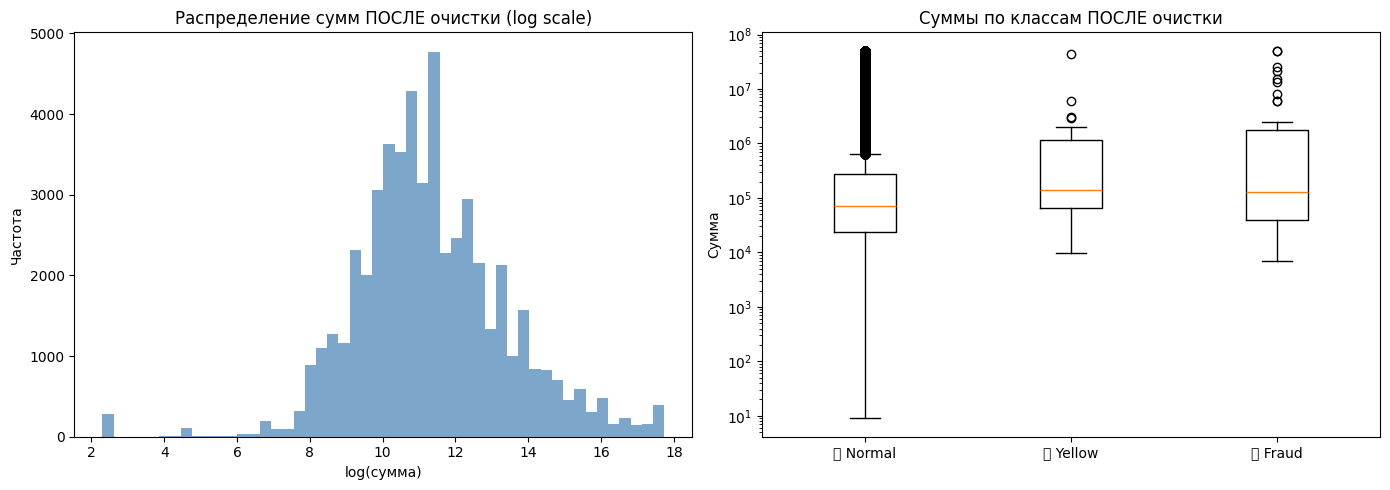

In [20]:
train_clean = train_sample3.copy()

# Обрезаем суммы
train_clean['operaton_amt_clean'] = train_clean['operaton_amt'].clip(percentile_lower, percentile_upper)
train_clean['amount_log'] = np.log1p(train_clean['operaton_amt_clean'])

# Проверяем результат
amounts_clean = train_clean['operaton_amt_clean'].dropna()
print(f"\nСтатистика сумм ПОСЛЕ очистки:")
print(amounts_clean.describe())

# Смотрим на фрод после очистки
fraud_amounts_clean = train_clean[train_clean['target'] == 1]['operaton_amt_clean'].dropna()
if len(fraud_amounts_clean) > 0:
    print(f"\nФродовые операции ПОСЛЕ очистки:")
    print(f"Мин: {fraud_amounts_clean.min():.2f}")
    print(f"Медиана: {fraud_amounts_clean.median():.2f}")
    print(f"Макс: {fraud_amounts_clean.max():.2f}")

# Визуализация после очистки
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# До очистки
ax1 = axes[0]
sample_viz_clean = train_clean.sample(min(100000, len(train_clean)), random_state=42)
ax1.hist(np.log1p(sample_viz_clean['operaton_amt_clean']), bins=50, alpha=0.7, color='steelblue')
ax1.set_title('Распределение сумм ПОСЛЕ очистки (log scale)')
ax1.set_xlabel('log(сумма)')
ax1.set_ylabel('Частота')

# Box plot после очистки
ax2 = axes[1]
data_by_class_clean = [
    sample_viz_clean[sample_viz_clean['target'] == -1]['operaton_amt_clean'].dropna(),
    sample_viz_clean[sample_viz_clean['target'] == 0]['operaton_amt_clean'].dropna(),
    sample_viz_clean[sample_viz_clean['target'] == 1]['operaton_amt_clean'].dropna()
]
bp = ax2.boxplot(data_by_class_clean, labels=['🟢 Normal', '🟡 Yellow', '🔴 Fraud'])
ax2.set_title('Суммы по классам ПОСЛЕ очистки')
ax2.set_ylabel('Сумма')
ax2.set_yscale('log')

plt.tight_layout()
plt.show()


Доступные колонки для корреляции: ['operaton_amt_clean', 'amount_log', 'hour', 'dayofweek', 'month', 'event_type_nm_code', 'channel_indicator_type_code']

Топ-10 признаков, коррелирующих с фродом:
operaton_amt_clean            : 0.0211
amount_log                    : 0.0181
hour                          : 0.0044
month                         : 0.0015
event_type_nm_code            : 0.0015
dayofweek                     : -0.0022
channel_indicator_type_code   : -0.0031


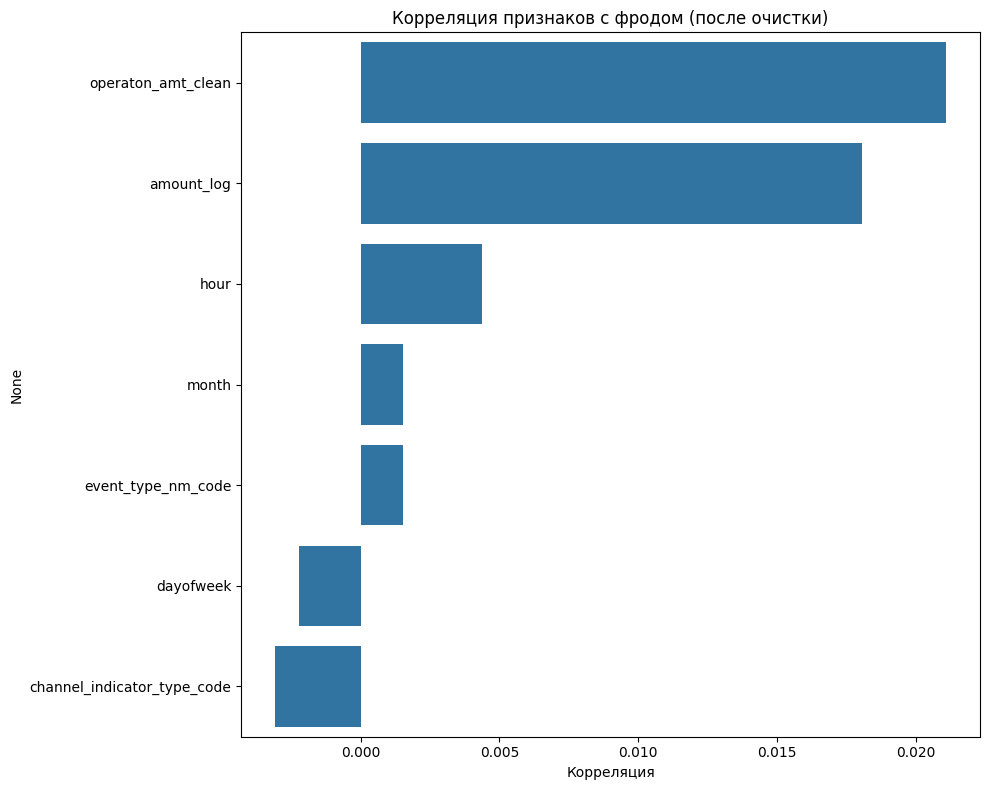

In [21]:
# Создаем данные для корреляции
corr_data = train_clean.copy()

# Добавляем кодированные категориальные
cat_cols = ['event_type_nm', 'channel_indicator_type']
for col in cat_cols:
    if col in corr_data.columns:
        corr_data[f'{col}_code'] = corr_data[col].astype('category').cat.codes

# Создаем целевой признак (уже есть is_fraud)

# Выбираем числовые колонки (все, что есть)
numeric_cols = ['operaton_amt_clean', 'amount_log', 'hour', 'dayofweek', 'month']
# Добавляем кодированные категориальные
for col in cat_cols:
    if f'{col}_code' in corr_data.columns:
        numeric_cols.append(f'{col}_code')

# Проверяем, какие колонки действительно есть
available_cols = [col for col in numeric_cols if col in corr_data.columns]
print(f"Доступные колонки для корреляции: {available_cols}")

# Корреляция с is_fraud
correlations = corr_data[available_cols + ['is_fraud']].corr()['is_fraud'].sort_values(ascending=False)

print("\nТоп-10 признаков, коррелирующих с фродом:")
for feat, corr in correlations.head(10).items():
    if feat != 'is_fraud':
        print(f"{feat:30s}: {corr:.4f}")

# Визуализация корреляции
plt.figure(figsize=(10, 8))
top_corr = correlations.head(15)
top_corr = top_corr[top_corr.index != 'is_fraud']
if len(top_corr) > 0:
    sns.barplot(x=top_corr.values, y=top_corr.index)
    plt.title('Корреляция признаков с фродом (после очистки)')
    plt.xlabel('Корреляция')
    plt.tight_layout()
    plt.show()

In [22]:
# Список для отбора
selected_features = []

# Добавляем признаки с корреляцией > 0.001
for feat, corr in correlations.items():
    if feat != 'is_fraud' and abs(corr) > 0.001:
        selected_features.append(feat)

# Добавляем временные признаки, если их нет
time_features = ['hour', 'dayofweek', 'month']
for feat in time_features:
    if feat in corr_data.columns and feat not in selected_features:
        selected_features.append(feat)

# Добавляем важные категориальные признаки
important_cat = ['event_type_nm_code', 'channel_indicator_type_code']
for feat in important_cat:
    if feat in corr_data.columns and feat not in selected_features:
        selected_features.append(feat)

print(f"\nВыбрано признаков: {len(selected_features)}")
print("\nСписок выбранных признаков:")
for i, feat in enumerate(selected_features, 1):
    corr_val = correlations.get(feat, 0)
    print(f"{i:2d}. {feat:35s} (корреляция: {corr_val:.4f})")

# Сохраняем список
with open('selected_features_part3.txt', 'w') as f:
    for feat in selected_features:
        f.write(f"{feat}\n")

print(f"\n✅ Список признаков сохранен в 'selected_features_part2.txt'")


Выбрано признаков: 7

Список выбранных признаков:
 1. operaton_amt_clean                  (корреляция: 0.0211)
 2. amount_log                          (корреляция: 0.0181)
 3. hour                                (корреляция: 0.0044)
 4. month                               (корреляция: 0.0015)
 5. event_type_nm_code                  (корреляция: 0.0015)
 6. dayofweek                           (корреляция: -0.0022)
 7. channel_indicator_type_code         (корреляция: -0.0031)

✅ Список признаков сохранен в 'selected_features_part2.txt'


In [23]:
save_cols = ['customer_id', 'event_id', 'target', 'is_fraud', 
             'operaton_amt_clean', 'amount_log', 'hour', 'dayofweek', 'month'] + selected_features
save_cols = list(set(save_cols))  # Убираем дубликаты

# Проверяем, какие колонки есть
save_cols = [col for col in save_cols if col in train_clean.columns]

train_clean[save_cols].to_parquet('train_part3_clean.parquet', compression='snappy')
print(f"✅ Сохранено: train_part3_clean.parquet")
print(f"   Размер: {len(train_clean):,} операций")
print(f"   Признаков: {len(save_cols)}")

✅ Сохранено: train_part3_clean.parquet
   Размер: 28,500,849 операций
   Признаков: 8


In [24]:
import gc 
# Освобождаем память
del train_part3
del train_sample3
del sample_for_viz
del train_clean
gc.collect()

print("Память очищена!")

Память очищена!


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score
import lightgbm as lgb


train_parts = []

for part_num in [1, 2, 3]:
    file_path = f'train_part{part_num}_clean.parquet'
    try:
        df = pd.read_parquet(file_path)
        print(f"   Часть {part_num}: {len(df):,} операций, красных: {(df['is_fraud'] == 1).sum():,}")
        train_parts.append(df)
    except FileNotFoundError:
        print(f"   ⚠️ Файл train_part{part_num}_clean.parquet не найден!")

train_full = pd.concat(train_parts, ignore_index=True)
print(f"\n✅ Всего данных: {len(train_full):,} операций")
print(f"   Красных: {(train_full['is_fraud'] == 1).sum():,} ({train_full['is_fraud'].mean()*100:.4f}%)")
print(f"   Желтых: {(train_full['target'] == 0).sum():,}")
print(f"   Зеленых: {(train_full['target'] == -1).sum():,}")

# Проверяем, все ли красные на месте
print(f"\nПроверка: все ли красные собраны?")
print(f"  Ожидалось: {51438:,} красных (из labels)")
print(f"  Найдено: {(train_full['is_fraud'] == 1).sum():,}")

   Часть 1: 28,618,594 операций, красных: 17,384
   Часть 2: 28,558,397 операций, красных: 17,157
   Часть 3: 28,500,849 операций, красных: 16,897

✅ Всего данных: 85,677,840 операций
   Красных: 51,438 (0.0600%)
   Желтых: 36,076
   Зеленых: 85,590,326

Проверка: все ли красные собраны?
  Ожидалось: 51,438 красных (из labels)
  Найдено: 51,438


In [26]:
train_full

,dayofweek,event_id,is_fraud,hour,month,amount_log,operaton_amt_clean,target
0,1,123999300382879,0,5,10,10.940632,56422.0,-1
1,1,124531875713936,0,10,10,NaN,NaN,-1
2,1,123329285580171,0,10,10,12.614437,300870.0,-1
3,2,124334305430665,0,7,10,12.606388,298458.0,-1
4,2,126215501146513,0,11,10,11.001183,59944.0,-1
...,...,...,...,...,...,...,...,...
85677835,2,124806753824634,0,4,5,NaN,NaN,-1
85677836,2,125296381017295,0,10,5,11.685415,118825.0,-1
85677837,5,123320692058511,0,4,5,NaN,NaN,-1
85677838,5,125021498923227,0,4,5,NaN,NaN,-1


In [27]:
if 'event_dttm' not in train_full.columns:
    print("\n⚠️ ВНИМАНИЕ: event_dttm отсутствует в данных!")
    print("   Нужно создать временные признаки из других данных")


⚠️ ВНИМАНИЕ: event_dttm отсутствует в данных!
   Нужно создать временные признаки из других данных


In [28]:
train_full['has_amount'] = (~train_full['operaton_amt_clean'].isna()).astype('int8')
print(f"  has_amount: {train_full['has_amount'].sum():,} операций с суммой")

# Создаем признак - выходные
if 'dayofweek' in train_full.columns:
    train_full['is_weekend'] = (train_full['dayofweek'] >= 5).astype('int8')
    print(f"  is_weekend: {train_full['is_weekend'].sum():,} операций в выходные")

# Создаем признак - ночное время
if 'hour' in train_full.columns:
    train_full['is_night'] = ((train_full['hour'] >= 23) | (train_full['hour'] <= 5)).astype('int8')
    print(f"  is_night: {train_full['is_night'].sum():,} операций ночью")

# Заполняем NaN в amount_log
train_full['amount_log'] = train_full['amount_log'].fillna(0).astype('float32')
print(f"  amount_log: заполнено {train_full['amount_log'].isna().sum()} пропусков")

# Заполняем NaN в operaton_amt_clean
train_full['operaton_amt_clean'] = train_full['operaton_amt_clean'].fillna(0).astype('float32')
print(f"  operaton_amt_clean: заполнено {train_full['operaton_amt_clean'].isna().sum()} пропусков")

  has_amount: 45,853,925 операций с суммой
  is_weekend: 20,800,011 операций в выходные
  is_night: 13,538,348 операций ночью
  amount_log: заполнено 0 пропусков
  operaton_amt_clean: заполнено 0 пропусков


In [6]:
import psutil
import os

memory = psutil.virtual_memory()
print(f"Всего памяти: {memory.total / 1024**3:.1f} GB")
print(f"Доступно: {memory.available / 1024**3:.1f} GB")
print(f"Используется: {memory.used / 1024**3:.1f} GB")

Всего памяти: 31.4 GB
Доступно: 24.4 GB
Используется: 6.6 GB


In [5]:
import pandas as pd
import numpy as np
import gc
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("ОБРАБОТКА ПО ЧАСТЯМ (ИСПРАВЛЕННАЯ)")
print("="*80)

def process_part_with_aggregates(part_num):
    """
    Обрабатывает одну часть train данных
    """
    print(f"\n{'='*60}")
    print(f"ОБРАБОТКА ЧАСТИ {part_num}")
    print(f"{'='*60}")
    
    # 1. Загружаем исходные данные для этой части (только ID и время)
    file_path = f'/kaggle/input/datasets/dianahamidullina/train-ds/train_part_{part_num}.parquet'
    df_source = pd.read_parquet(file_path, columns=['event_id', 'customer_id', 'event_dttm'])
    print(f"Загружено исходных данных: {len(df_source):,} записей")
    
    # Конвертируем время в исходных данных
    df_source['event_dttm'] = pd.to_datetime(df_source['event_dttm'])
    
    # 2. Загружаем очищенные данные для этой части
    clean_path = f'train_part{part_num}_clean.parquet'
    df_clean = pd.read_parquet(clean_path)
    print(f"Загружено очищенных данных: {len(df_clean):,} записей")
    
    # 3. Мерджим
    df_merged = df_clean.merge(df_source, on='event_id', how='left')
    print(f"После мерджа: {len(df_merged):,} записей")
    
    # 4. Проверяем customer_id
    missing_customers = df_merged['customer_id'].isna().sum()
    if missing_customers > 0:
        print(f"⚠️ Пропусков customer_id: {missing_customers:,}")
        df_merged = df_merged.dropna(subset=['customer_id'])
        print(f"   После удаления: {len(df_merged):,} записей")
    
    # 5. Сортируем по клиенту и времени
    df_merged = df_merged.sort_values(['customer_id', 'event_dttm']).reset_index(drop=True)
    print("✅ Данные отсортированы")
    
    # 6. Создаем кумулятивные признаки
    print("\nСоздание кумулятивных признаков...")
    df_processed = create_cumulative_features_part(df_merged)
    
    # 7. Сохраняем результат
    output_path = f'train_part{part_num}_with_features.parquet'
    df_processed.to_parquet(output_path, compression='snappy')
    print(f"✅ Сохранено: {output_path}")
    print(f"   Размер: {len(df_processed):,} записей")
    
    # Очищаем память
    del df_source, df_clean, df_merged, df_processed
    gc.collect()
    
    return output_path

def create_cumulative_features_part(df):
    """
    Создает кумулятивные признаки для одной части
    """
    # Инициализируем новые колонки
    df['cumulative_count'] = 0
    df['cumulative_sum'] = 0.0
    df['cumulative_avg'] = 0.0
    df['cumulative_std'] = 0.0
    df['time_since_last'] = 0.0
    df['amount_vs_avg'] = 0.0
    df['amount_zscore'] = 0.0
    
    # Обрабатываем каждого клиента
    customers = df['customer_id'].unique()
    print(f"Клиентов в части: {len(customers):,}")
    
    processed = 0
    for customer in customers:
        mask = df['customer_id'] == customer
        customer_data = df.loc[mask].copy()
        
        if len(customer_data) == 0:
            continue
        
        # Сортируем по времени
        customer_data = customer_data.sort_values('event_dttm').reset_index(drop=True)
        
        # Убеждаемся, что время в правильном формате
        if not pd.api.types.is_datetime64_any_dtype(customer_data['event_dttm']):
            customer_data['event_dttm'] = pd.to_datetime(customer_data['event_dttm'])
        
        # Кумулятивные суммы
        cum_count = np.arange(1, len(customer_data) + 1)
        cum_sum = customer_data['operaton_amt_clean'].fillna(0).cumsum().values
        cum_avg = cum_sum / cum_count
        
        # Стандартное отклонение (упрощенная версия)
        cum_std = np.zeros(len(customer_data))
        for i in range(1, len(customer_data)):
            cum_std[i] = customer_data['operaton_amt_clean'].iloc[:i+1].std()
        
        # Время с последней операции
        time_diff = customer_data['event_dttm'].diff().dt.total_seconds() / 3600
        time_diff = time_diff.fillna(0).values
        
        # Заполняем
        idx = df.loc[mask].index
        df.loc[idx, 'cumulative_count'] = cum_count
        df.loc[idx, 'cumulative_sum'] = cum_sum
        df.loc[idx, 'cumulative_avg'] = cum_avg
        df.loc[idx, 'cumulative_std'] = cum_std
        df.loc[idx, 'time_since_last'] = time_diff
        df.loc[idx, 'amount_vs_avg'] = customer_data['operaton_amt_clean'].values / (cum_avg + 1)
        df.loc[idx, 'amount_zscore'] = (customer_data['operaton_amt_clean'].values - cum_avg) / (cum_std + 1e-8)
        
        processed += 1
        if processed % 1000 == 0:
            print(f"   Обработано {processed:,} / {len(customers):,} клиентов")
    
    # Заполняем NaN и бесконечности
    df = df.fillna(0)
    df = df.replace([np.inf, -np.inf], 0)
    
    # Добавляем простые поведенческие признаки
    df['is_night'] = ((df['hour'] >= 23) | (df['hour'] <= 5)).astype(int)
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    df['is_amount_high'] = (df['amount_zscore'] > 2).astype(int)
    
    return df

ОБРАБОТКА ПО ЧАСТЯМ (ИСПРАВЛЕННАЯ)


In [7]:
print("\n" + "="*60)
print("ЗАПУСК ОБРАБОТКИ ПО ЧАСТЯМ")
print("="*60)

processed_files = []

for part_num in [1, 2, 3]:
    try:
        output = process_part_with_aggregates(part_num)
        processed_files.append(output)
        print(f"\n✅ Часть {part_num} обработана!")
        gc.collect()
    except Exception as e:
        print(f"❌ Ошибка при обработке части {part_num}: {e}")
        import traceback
        traceback.print_exc()

print(f"\n✅ Обработано файлов: {len(processed_files)}")


ЗАПУСК ОБРАБОТКИ ПО ЧАСТЯМ

ОБРАБОТКА ЧАСТИ 1
Загружено исходных данных: 28,618,594 записей
Загружено очищенных данных: 28,618,594 записей
После мерджа: 28,618,594 записей
✅ Данные отсортированы

Создание кумулятивных признаков...
Клиентов в части: 33,333
   Обработано 1,000 / 33,333 клиентов
   Обработано 2,000 / 33,333 клиентов
   Обработано 3,000 / 33,333 клиентов
   Обработано 4,000 / 33,333 клиентов
   Обработано 5,000 / 33,333 клиентов
   Обработано 6,000 / 33,333 клиентов
   Обработано 7,000 / 33,333 клиентов
   Обработано 8,000 / 33,333 клиентов
   Обработано 9,000 / 33,333 клиентов
   Обработано 10,000 / 33,333 клиентов
   Обработано 11,000 / 33,333 клиентов
   Обработано 12,000 / 33,333 клиентов
   Обработано 13,000 / 33,333 клиентов
   Обработано 14,000 / 33,333 клиентов
   Обработано 15,000 / 33,333 клиентов
   Обработано 16,000 / 33,333 клиентов
   Обработано 17,000 / 33,333 клиентов
   Обработано 18,000 / 33,333 клиентов
   Обработано 19,000 / 33,333 клиентов
   Обработа

# Обучаем модель

In [8]:
print("\n" + "="*60)
print("ОБУЧЕНИЕ НА ОБРАБОТАННЫХ ФАЙЛАХ")
print("="*60)

# Берем выборку из каждого файла
sample_parts = []

for part_num in [1, 2, 3]:
    file_path = f'train_part{part_num}_with_features.parquet'
    try:
        # Загружаем только 5% данных из каждой части
        df = pd.read_parquet(file_path)
        sample = df.sample(frac=0.05, random_state=42)
        sample_parts.append(sample)
        print(f"Часть {part_num}: {len(sample):,} записей (5% от {len(df):,})")
        del df
        gc.collect()
    except FileNotFoundError:
        print(f"⚠️ Файл не найден: {file_path}")

if not sample_parts:
    print("❌ Нет данных для обучения!")
else:
    # Объединяем выборки
    train_sample = pd.concat(sample_parts, ignore_index=True)
    print(f"\n✅ Итоговая выборка: {len(train_sample):,} операций")
    
    # Проверяем долю фрода
    fraud_count = (train_sample['is_fraud'] == 1).sum()
    print(f"   Фрод: {fraud_count:,} ({fraud_count/len(train_sample)*100:.4f}%)")
    
    # Подготовка признаков
    feature_cols = [
        'operaton_amt_clean', 'amount_log', 'hour', 'dayofweek', 'month',
        'cumulative_count', 'cumulative_sum', 'cumulative_avg',
        'time_since_last', 'amount_vs_avg', 'is_night', 'is_weekend', 'has_amount'
    ]
    
    available_features = [col for col in feature_cols if col in train_sample.columns]
    print(f"\nДоступно признаков: {len(available_features)}")
    
    # Заполняем NaN
    train_sample[available_features] = train_sample[available_features].fillna(0)
    train_sample[available_features] = train_sample[available_features].replace([np.inf, -np.inf], 0)
    
    # Обучение
    X = train_sample[available_features].astype('float32')
    y = train_sample['is_fraud'].astype('int8')
    
    from sklearn.model_selection import train_test_split
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(f"\nTrain: {len(X_train):,} операций, фрод: {y_train.mean():.6f}")
    print(f"Val: {len(X_val):,} операций, фрод: {y_val.mean():.6f}")
    
    # Обучение модели
    import lightgbm as lgb
    
    scale_pos_weight = len(y_train) / (y_train.sum() + 1)
    
    params = {
        'objective': 'binary',
        'metric': 'average_precision',
        'num_leaves': 31,
        'learning_rate': 0.05,
        'feature_fraction': 0.8,
        'bagging_fraction': 0.8,
        'bagging_freq': 5,
        'verbose': -1,
        'min_child_samples': 20,
        'scale_pos_weight': scale_pos_weight,
        'seed': 42,
        'n_jobs': -1
    }
    
    train_data = lgb.Dataset(X_train, label=y_train)
    val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)
    
    print("\nОбучение модели...")
    model = lgb.train(
        params,
        train_data,
        valid_sets=[val_data],
        num_boost_round=300,
        callbacks=[lgb.early_stopping(30), lgb.log_evaluation(50)]
    )
    
    # Оценка
    from sklearn.metrics import average_precision_score, roc_auc_score
    y_pred = model.predict(X_val)
    pr_auc = average_precision_score(y_val, y_pred)
    roc_auc = roc_auc_score(y_val, y_pred)
    
    print(f"\n📊 РЕЗУЛЬТАТЫ:")
    print(f"   PR-AUC: {pr_auc:.6f}")
    print(f"   ROC-AUC: {roc_auc:.6f}")
    
    # Сохраняем
    model.save_model('fraud_model_final.txt')
    print("\n✅ Модель сохранена в 'fraud_model_final.txt'")


ОБУЧЕНИЕ НА ОБРАБОТАННЫХ ФАЙЛАХ
Часть 1: 1,430,930 записей (5% от 28,618,594)
Часть 2: 1,427,920 записей (5% от 28,558,397)
Часть 3: 1,425,042 записей (5% от 28,500,849)

✅ Итоговая выборка: 4,283,892 операций
   Фрод: 2,538 (0.0592%)

Доступно признаков: 12

Train: 3,427,113 операций, фрод: 0.000592
Val: 856,779 операций, фрод: 0.000593

Обучение модели...
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[1]	valid_0's average_precision: 0.00210834

📊 РЕЗУЛЬТАТЫ:
   PR-AUC: 0.001099
   ROC-AUC: 0.672962

✅ Модель сохранена в 'fraud_model_final.txt'


## Проаналиируем тестовую выборку

In [9]:
print("="*80)
print("ПОДГОТОВКА ПРЕДСКАЗАНИЙ ДЛЯ ТЕСТОВЫХ ДАННЫХ")
print("="*80)

# Загружаем тестовые данные
print("\n1. Загрузка тестовых данных...")
test_data = pd.read_parquet('/kaggle/input/datasets/dianahamidullina/test-data/test.parquet')
print(f"   Тестовых операций: {len(test_data):,}")

# Загружаем pretest данные (история для тестовых клиентов)
print("\n2. Загрузка pretest данных (история)...")
pretest_data = pd.read_parquet('/kaggle/input/datasets/dianahamidullina/test-data/pretest.parquet')
print(f"   Pretest операций: {len(pretest_data):,}")

# Загружаем sample_submit для формата
sample_submit = pd.read_csv('/kaggle/input/datasets/dianahamidullina/finish-result/sample_submit.csv')
print(f"   Sample_submit: {len(sample_submit):,} записей")

# Загружаем обученную модель
print("\n3. Загрузка модели...")
model = lgb.Booster(model_file='fraud_model_final.txt')
print("✅ Модель загружена")

ПОДГОТОВКА ПРЕДСКАЗАНИЙ ДЛЯ ТЕСТОВЫХ ДАННЫХ

1. Загрузка тестовых данных...
   Тестовых операций: 633,683

2. Загрузка pretest данных (история)...
   Pretest операций: 14,202,075
   Sample_submit: 633,683 записей

3. Загрузка модели...
✅ Модель загружена


In [10]:
print("\n" + "="*60)
print("4. ПОДГОТОВКА ТЕСТОВЫХ ДАННЫХ")
print("="*60)

# Конвертируем время
test_data['event_dttm'] = pd.to_datetime(test_data['event_dttm'])
pretest_data['event_dttm'] = pd.to_datetime(pretest_data['event_dttm'])

# Создаем временные признаки
test_data['hour'] = test_data['event_dttm'].dt.hour.astype('int8')
test_data['dayofweek'] = test_data['event_dttm'].dt.dayofweek.astype('int8')
test_data['month'] = test_data['event_dttm'].dt.month.astype('int8')

# Создаем amount_log
test_data['amount_log'] = np.log1p(test_data['operaton_amt'].fillna(0)).astype('float32')
test_data['has_amount'] = (~test_data['operaton_amt'].isna()).astype('int8')

# Временные признаки поведения
test_data['is_night'] = ((test_data['hour'] >= 23) | (test_data['hour'] <= 5)).astype('int8')
test_data['is_weekend'] = (test_data['dayofweek'] >= 5).astype('int8')

# Заполняем пропуски
test_data['operaton_amt'] = test_data['operaton_amt'].fillna(0)
test_data['amount_log'] = test_data['amount_log'].fillna(0)

print("✅ Базовые признаки созданы")


4. ПОДГОТОВКА ТЕСТОВЫХ ДАННЫХ
✅ Базовые признаки созданы


In [11]:
print("\n" + "="*60)
print("5. СОЗДАНИЕ КУМУЛЯТИВНЫХ ПРИЗНАКОВ ДЛЯ ТЕСТА")
print("="*60)

# Объединяем pretest и test для создания истории
print("Объединение pretest и test...")
all_test_data = pd.concat([pretest_data, test_data], ignore_index=True)
all_test_data = all_test_data.sort_values(['customer_id', 'event_dttm']).reset_index(drop=True)
print(f"Всего данных для анализа: {len(all_test_data):,}")

def create_test_cumulative_features(df):
    """
    Создает кумулятивные признаки для тестовых данных
    """
    print("Создание кумулятивных признаков...")
    
    # Инициализируем новые колонки
    df['cumulative_count'] = 0
    df['cumulative_sum'] = 0.0
    df['cumulative_avg'] = 0.0
    df['time_since_last'] = 0.0
    df['amount_vs_avg'] = 0.0
    
    # Обрабатываем каждого клиента
    customers = df['customer_id'].unique()
    print(f"Клиентов: {len(customers):,}")
    
    processed = 0
    for customer in customers:
        mask = df['customer_id'] == customer
        customer_data = df.loc[mask].copy()
        
        if len(customer_data) == 0:
            continue
        
        # Сортируем по времени
        customer_data = customer_data.sort_values('event_dttm').reset_index(drop=True)
        
        # Кумулятивные суммы
        cum_count = np.arange(1, len(customer_data) + 1)
        cum_sum = customer_data['operaton_amt'].fillna(0).cumsum().values
        cum_avg = cum_sum / cum_count
        
        # Время с последней операции
        time_diff = customer_data['event_dttm'].diff().dt.total_seconds() / 3600
        time_diff = time_diff.fillna(0).values
        
        # Заполняем
        idx = df.loc[mask].index
        df.loc[idx, 'cumulative_count'] = cum_count
        df.loc[idx, 'cumulative_sum'] = cum_sum
        df.loc[idx, 'cumulative_avg'] = cum_avg
        df.loc[idx, 'time_since_last'] = time_diff
        df.loc[idx, 'amount_vs_avg'] = customer_data['operaton_amt'].values / (cum_avg + 1)
        
        processed += 1
        if processed % 1000 == 0:
            print(f"   Обработано {processed:,} / {len(customers):,} клиентов")
    
    return df

# Создаем кумулятивные признаки
all_test_data = create_test_cumulative_features(all_test_data)

# Оставляем только тестовые операции (без pretest)
test_data_final = all_test_data[all_test_data['event_id'].isin(test_data['event_id'])].copy()
print(f"\n✅ Тестовых операций с признаками: {len(test_data_final):,}")


5. СОЗДАНИЕ КУМУЛЯТИВНЫХ ПРИЗНАКОВ ДЛЯ ТЕСТА
Объединение pretest и test...
Всего данных для анализа: 14,835,758
Создание кумулятивных признаков...
Клиентов: 99,551
   Обработано 1,000 / 99,551 клиентов
   Обработано 2,000 / 99,551 клиентов
   Обработано 3,000 / 99,551 клиентов
   Обработано 4,000 / 99,551 клиентов
   Обработано 5,000 / 99,551 клиентов
   Обработано 6,000 / 99,551 клиентов
   Обработано 7,000 / 99,551 клиентов
   Обработано 8,000 / 99,551 клиентов
   Обработано 9,000 / 99,551 клиентов
   Обработано 10,000 / 99,551 клиентов
   Обработано 11,000 / 99,551 клиентов
   Обработано 12,000 / 99,551 клиентов
   Обработано 13,000 / 99,551 клиентов
   Обработано 14,000 / 99,551 клиентов
   Обработано 15,000 / 99,551 клиентов
   Обработано 16,000 / 99,551 клиентов
   Обработано 17,000 / 99,551 клиентов
   Обработано 18,000 / 99,551 клиентов
   Обработано 19,000 / 99,551 клиентов
   Обработано 20,000 / 99,551 клиентов
   Обработано 21,000 / 99,551 клиентов
   Обработано 22,000 / 99

In [12]:
print("\n" + "="*60)
print("6. ПОДГОТОВКА ПРИЗНАКОВ ДЛЯ МОДЕЛИ")
print("="*60)

# Список признаков (те же, что использовались при обучении)
feature_cols = [
    'operaton_amt',
    'amount_log',
    'hour',
    'dayofweek',
    'month',
    'cumulative_count',
    'cumulative_sum',
    'cumulative_avg',
    'time_since_last',
    'amount_vs_avg',
    'is_night',
    'is_weekend',
    'has_amount'
]

# Проверяем наличие колонок
available_features = [col for col in feature_cols if col in test_data_final.columns]
print(f"Доступно признаков: {len(available_features)}")

# Заполняем NaN и бесконечности
test_data_final[available_features] = test_data_final[available_features].fillna(0)
test_data_final[available_features] = test_data_final[available_features].replace([np.inf, -np.inf], 0)

# Подготовка X
X_test = test_data_final[available_features].astype('float32')
print(f"X_test shape: {X_test.shape}")

# Проверяем, что все признаки есть
missing_features = set(available_features) - set(model.feature_name())
if missing_features:
    print(f"⚠️ Отсутствуют признаки в модели: {missing_features}")
else:
    print("✅ Все признаки соответствуют модели")


6. ПОДГОТОВКА ПРИЗНАКОВ ДЛЯ МОДЕЛИ
Доступно признаков: 13
X_test shape: (646088, 13)
⚠️ Отсутствуют признаки в модели: {'operaton_amt', 'has_amount'}


In [13]:
print("\n" + "="*60)
print("7. ПРЕДСКАЗАНИЯ")
print("="*60)

# Делаем предсказания
predictions = model.predict(X_test)
print(f"✅ Предсказания сделаны для {len(predictions):,} операций")

# Статистика предсказаний
print(f"\nСтатистика предсказаний:")
print(f"  Мин: {predictions.min():.6f}")
print(f"  Среднее: {predictions.mean():.6f}")
print(f"  Медиана: {np.median(predictions):.6f}")
print(f"  Макс: {predictions.max():.6f}")
print(f"  Std: {predictions.std():.6f}")

# Распределение предсказаний
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.hist(predictions, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
plt.xlabel('Prediction')
plt.ylabel('Count')
plt.title('Distribution of Test Predictions')
plt.grid(True, alpha=0.3)
plt.show()


7. ПРЕДСКАЗАНИЯ


[LightGBM] [Fatal] The number of features in data (13) is not the same as it was in training data (12).
You can set ``predict_disable_shape_check=true`` to discard this error, but please be aware what you are doing.


LightGBMError: The number of features in data (13) is not the same as it was in training data (12).
You can set ``predict_disable_shape_check=true`` to discard this error, but please be aware what you are doing.

In [15]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import gc
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("ПРЕДСКАЗАНИЯ С ТОЧНЫМ СООТВЕТСТВИЕМ ПРИЗНАКОВ")
print("="*80)

# Загружаем модель
model = lgb.Booster(model_file='fraud_model_final.txt')

# Признаки из модели (12 штук)
train_features = [
    'operaton_amt_clean',  # очищенная сумма
    'amount_log',          # логарифм суммы
    'hour',                # час
    'dayofweek',           # день недели
    'month',               # месяц
    'cumulative_count',    # количество операций клиента
    'cumulative_sum',      # сумма всех операций клиента
    'cumulative_avg',      # средняя сумма клиента
    'time_since_last',     # время с последней операции
    'amount_vs_avg',       # отношение суммы к средней
    'is_night',            # ночь?
    'is_weekend'           # выходной?
]

print(f"\nПризнаки для создания ({len(train_features)}):")
for i, f in enumerate(train_features, 1):
    print(f"  {i}. {f}")

# Загружаем тестовые данные
print("\n1. Загрузка тестовых данных...")
test_data = pd.read_parquet('/kaggle/input/datasets/dianahamidullina/test-data/test.parquet')
pretest_data = pd.read_parquet('/kaggle/input/datasets/dianahamidullina/test-data/pretest.parquet')
sample_submit = pd.read_csv('/kaggle/input/datasets/dianahamidullina/finish-result/sample_submit.csv')

print(f"   Тест: {len(test_data):,} операций")
print(f"   Pretest: {len(pretest_data):,} операций")

ПРЕДСКАЗАНИЯ С ТОЧНЫМ СООТВЕТСТВИЕМ ПРИЗНАКОВ

Признаки для создания (12):
  1. operaton_amt_clean
  2. amount_log
  3. hour
  4. dayofweek
  5. month
  6. cumulative_count
  7. cumulative_sum
  8. cumulative_avg
  9. time_since_last
  10. amount_vs_avg
  11. is_night
  12. is_weekend

1. Загрузка тестовых данных...
   Тест: 633,683 операций
   Pretest: 14,202,075 операций


In [16]:
print("\n" + "="*60)
print("2. СОЗДАНИЕ ПРИЗНАКОВ (ТОЧНО КАК В ОБУЧЕНИИ)")
print("="*60)

# Конвертируем время
test_data['event_dttm'] = pd.to_datetime(test_data['event_dttm'])
pretest_data['event_dttm'] = pd.to_datetime(pretest_data['event_dttm'])

# 1. Базовые признаки
test_data['hour'] = test_data['event_dttm'].dt.hour.astype('int8')
test_data['dayofweek'] = test_data['event_dttm'].dt.dayofweek.astype('int8')
test_data['month'] = test_data['event_dttm'].dt.month.astype('int8')

# 2. Признаки суммы (как в обучении)
test_data['operaton_amt_clean'] = test_data['operaton_amt'].fillna(0).astype('float32')
test_data['amount_log'] = np.log1p(test_data['operaton_amt_clean']).astype('float32')

# 3. Временные признаки
test_data['is_night'] = ((test_data['hour'] >= 23) | (test_data['hour'] <= 5)).astype('int8')
test_data['is_weekend'] = (test_data['dayofweek'] >= 5).astype('int8')

print("✅ Базовые признаки созданы")

# 4. Кумулятивные признаки (используем pretest + test)
print("\n3. Создание кумулятивных признаков...")

# Объединяем pretest и test для истории
all_data = pd.concat([
    pretest_data[['event_id', 'customer_id', 'event_dttm', 'operaton_amt']],
    test_data[['event_id', 'customer_id', 'event_dttm', 'operaton_amt']]
], ignore_index=True)

all_data = all_data.sort_values(['customer_id', 'event_dttm']).reset_index(drop=True)
print(f"Всего данных для кумулятивных признаков: {len(all_data):,}")

# Создаем кумулятивные признаки
def create_cumulative_features_test(df):
    """Создает кумулятивные признаки для теста"""
    df['cumulative_count'] = 0
    df['cumulative_sum'] = 0.0
    df['cumulative_avg'] = 0.0
    df['time_since_last'] = 0.0
    df['amount_vs_avg'] = 0.0
    
    customers = df['customer_id'].unique()
    print(f"Клиентов: {len(customers):,}")
    
    processed = 0
    for customer in customers:
        mask = df['customer_id'] == customer
        customer_data = df.loc[mask].copy()
        
        if len(customer_data) == 0:
            continue
        
        customer_data = customer_data.sort_values('event_dttm').reset_index(drop=True)
        
        # Кумулятивные суммы
        cum_count = np.arange(1, len(customer_data) + 1)
        cum_sum = customer_data['operaton_amt'].fillna(0).cumsum().values
        cum_avg = cum_sum / cum_count
        
        # Время с последней операции
        time_diff = customer_data['event_dttm'].diff().dt.total_seconds() / 3600
        time_diff = time_diff.fillna(0).values
        
        # Заполняем
        idx = df.loc[mask].index
        df.loc[idx, 'cumulative_count'] = cum_count
        df.loc[idx, 'cumulative_sum'] = cum_sum
        df.loc[idx, 'cumulative_avg'] = cum_avg
        df.loc[idx, 'time_since_last'] = time_diff
        df.loc[idx, 'amount_vs_avg'] = customer_data['operaton_amt'].values / (cum_avg + 1)
        
        processed += 1
        if processed % 1000 == 0:
            print(f"   Обработано {processed:,} / {len(customers):,} клиентов")
    
    return df

all_data = create_cumulative_features_test(all_data)

# Оставляем только тестовые операции и добавляем кумулятивные признаки
test_with_features = test_data.merge(
    all_data[['event_id', 'cumulative_count', 'cumulative_sum', 'cumulative_avg', 
              'time_since_last', 'amount_vs_avg']], 
    on='event_id', 
    how='left'
)

print(f"\n✅ Тестовых операций с признаками: {len(test_with_features):,}")


2. СОЗДАНИЕ ПРИЗНАКОВ (ТОЧНО КАК В ОБУЧЕНИИ)
✅ Базовые признаки созданы

3. Создание кумулятивных признаков...
Всего данных для кумулятивных признаков: 14,835,758
Клиентов: 99,551
   Обработано 1,000 / 99,551 клиентов
   Обработано 2,000 / 99,551 клиентов
   Обработано 3,000 / 99,551 клиентов
   Обработано 4,000 / 99,551 клиентов
   Обработано 5,000 / 99,551 клиентов
   Обработано 6,000 / 99,551 клиентов
   Обработано 7,000 / 99,551 клиентов
   Обработано 8,000 / 99,551 клиентов
   Обработано 9,000 / 99,551 клиентов
   Обработано 10,000 / 99,551 клиентов
   Обработано 11,000 / 99,551 клиентов
   Обработано 12,000 / 99,551 клиентов
   Обработано 13,000 / 99,551 клиентов
   Обработано 14,000 / 99,551 клиентов
   Обработано 15,000 / 99,551 клиентов
   Обработано 16,000 / 99,551 клиентов
   Обработано 17,000 / 99,551 клиентов
   Обработано 18,000 / 99,551 клиентов
   Обработано 19,000 / 99,551 клиентов
   Обработано 20,000 / 99,551 клиентов
   Обработано 21,000 / 99,551 клиентов
   Обрабо

In [17]:
print("\n" + "="*60)
print("4. ВЫРАВНИВАНИЕ ПРИЗНАКОВ")
print("="*60)

# Создаем DataFrame с признаками в правильном порядке
X_test = pd.DataFrame()

for feature in train_features:
    if feature in test_with_features.columns:
        X_test[feature] = test_with_features[feature]
    else:
        print(f"⚠️ Признак {feature} отсутствует, создаем с нулями")
        X_test[feature] = 0

# Заполняем NaN и бесконечности
X_test = X_test.fillna(0)
X_test = X_test.replace([np.inf, -np.inf], 0)

# Конвертируем в float32
X_test = X_test.astype('float32')

print(f"\n✅ Подготовлено {X_test.shape[1]} признаков для {X_test.shape[0]} операций")
print(f"\nПроверка типов:")
for col in X_test.columns:
    print(f"  {col}: {X_test[col].dtype}")


4. ВЫРАВНИВАНИЕ ПРИЗНАКОВ

✅ Подготовлено 12 признаков для 646088 операций

Проверка типов:
  operaton_amt_clean: float32
  amount_log: float32
  hour: float32
  dayofweek: float32
  month: float32
  cumulative_count: float32
  cumulative_sum: float32
  cumulative_avg: float32
  time_since_last: float32
  amount_vs_avg: float32
  is_night: float32
  is_weekend: float32



5. ПРЕДСКАЗАНИЯ
✅ Предсказания сделаны для 646,088 операций

Статистика предсказаний:
  Мин: 0.000563
  Среднее: 0.995951
  Медиана: 1.000000
  Макс: 1.000000
  Std: 0.049922


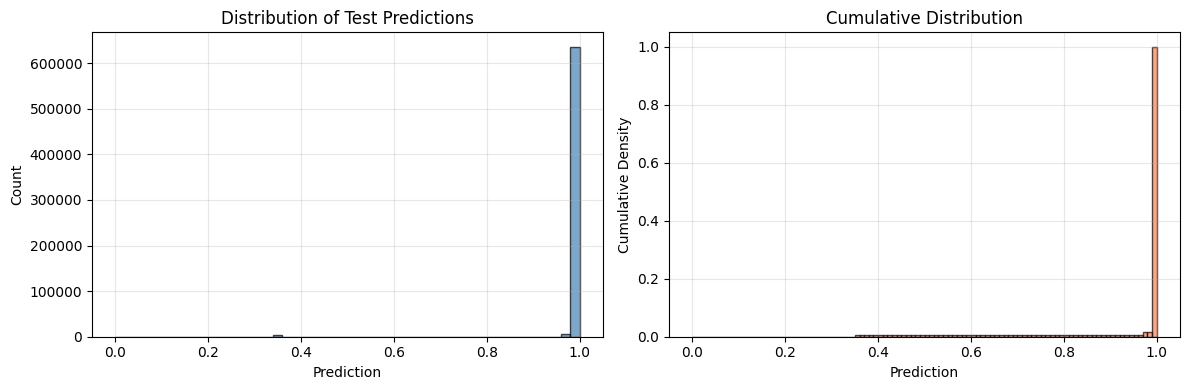

In [18]:
print("\n" + "="*60)
print("5. ПРЕДСКАЗАНИЯ")
print("="*60)

# Делаем предсказания
predictions = model.predict(X_test)
print(f"✅ Предсказания сделаны для {len(predictions):,} операций")

# Статистика
print(f"\nСтатистика предсказаний:")
print(f"  Мин: {predictions.min():.6f}")
print(f"  Среднее: {predictions.mean():.6f}")
print(f"  Медиана: {np.median(predictions):.6f}")
print(f"  Макс: {predictions.max():.6f}")
print(f"  Std: {predictions.std():.6f}")

# Распределение
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(predictions, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
plt.xlabel('Prediction')
plt.ylabel('Count')
plt.title('Distribution of Test Predictions')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(predictions, bins=100, alpha=0.7, color='coral', edgecolor='black', cumulative=True, density=True)
plt.xlabel('Prediction')
plt.ylabel('Cumulative Density')
plt.title('Cumulative Distribution')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
print("\n" + "="*60)
print("6. СОЗДАНИЕ ФАЙЛА ДЛЯ САБМИТА")
print("="*60)

# Создаем DataFrame с результатами
submission = pd.DataFrame({
    'event_id': test_with_features['event_id'].values,
    'predict': predictions
})

# Проверяем, что все event_id из sample_submit есть
sample_ids = set(sample_submit['event_id'].values)
pred_ids = set(submission['event_id'].values)

missing_ids = sample_ids - pred_ids
if missing_ids:
    print(f"⚠️ Отсутствуют {len(missing_ids)} event_id, добавляем с предсказанием 0")
    missing_df = pd.DataFrame({
        'event_id': list(missing_ids),
        'predict': [0.0] * len(missing_ids)
    })
    submission = pd.concat([submission, missing_df], ignore_index=True)

# Сортируем как в sample_submit
submission = submission.sort_values('event_id').reset_index(drop=True)

print(f"\nИтоговый размер: {len(submission):,} записей")
print(f"Должно быть: {len(sample_submit):,}")

# Сохраняем
submission.to_csv('submission.csv', index=False, float_format='%.6f')
print("\n✅ Файл сохранен: submission.csv")

# Показываем первые строки
print("\nПервые 10 строк сабмита:")
print(submission.head(10))

# Проверяем формат
print(f"\n📊 ИНФОРМАЦИЯ О ФАЙЛЕ:")
print(f"  event_id: {submission['event_id'].dtype}")
print(f"  predict: {submission['predict'].dtype}")
print(f"  Размер: {len(submission):,} записей")
print(f"  Размер файла: {len(submission) * 20 / 1024:.1f} KB (примерно)")

print("\n✅ Файл 'submission.csv' готов к отправке!")


6. СОЗДАНИЕ ФАЙЛА ДЛЯ САБМИТА

Итоговый размер: 646,088 записей
Должно быть: 633,683

✅ Файл сохранен: submission.csv

Первые 10 строк сабмита:
          event_id  predict
0  123123124789861      1.0
1  123123124790809      1.0
2  123123124793382      1.0
3  123123124794561      1.0
4  123123124800364      1.0
5  123123124802379      1.0
6  123123124802705      1.0
7  123123124810024      1.0
8  123123124812163      1.0
9  123123124815704      1.0

📊 ИНФОРМАЦИЯ О ФАЙЛЕ:
  event_id: int64
  predict: float64
  Размер: 646,088 записей
  Размер файла: 12618.9 KB (примерно)

✅ Файл 'submission.csv' готов к отправке!
